In [1005]:
import os
import re


from collections import Counter
from collections import defaultdict
import copy
import ast

import numpy as np
import pandas as pd
from IPython.display import display
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

In [1006]:
data = pd.read_csv(r'Запчасти списанные в ремонт.csv', skiprows=[0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=str)
data = data[data['Номенклатура.Артикул'].notna()]
data = data.drop(columns=['Unnamed: 1', 'Unnamed: 5', 'Unnamed: 6'])
data = data.iloc[:-1].reset_index(drop=True)
data = data[~(data['Номенклатура.Оригинальный номер'].isna() & data['Номенклатура.Артикул'].isna())]

conditions1 = [
    data['Машина'].str.contains('ножничный', case=False, na=False),
    data['Машина'].str.contains('коленчатый', case=False, na=False),
    data['Машина'].str.contains('телескопический', case=False, na=False),
    data['Машина'].str.contains('мачтовый', case=False, na=False)
]

choices1 = ['ножничный', 'коленчатый', 'телескопический', 'мачтовый']

data['Тип подъемника'] = np.select(conditions1, choices1, default='другое')

conditions2 = [

    data['Машина'].str.contains('электрический', case=False, na=False),
    data['Машина'].str.contains('дизельный', case=False, na=False),
]

choices2 = ['Электрический', 'Дизельный']

data['Тип двигателя'] = np.select(conditions2, choices2, default='другое')

data = data.loc[~(data['Тип подъемника'] == 'другое')]

data = data[~(data['Машина'].str.startswith("Телескопический погрузчик"))]

data.loc[data['Машина'] == 'Телескопический подъемник Zoomlion ZT72J-V', 'Тип двигателя'] = 'Дизельный'
data.loc[data['Машина'] == 'Телескопический подъемник Zoomlion ZT30J', 'Тип двигателя'] = 'Дизельный'

data['Дата'] = pd.to_datetime(data['Дата'], format='%d.%m.%Y %H:%M:%S')
data['Год'] = data['Дата'].dt.year
data['Квартал'] = data['Дата'].dt.quarter
data['Лот.CRM год выпуска'] = data['Лот.CRM год выпуска'].apply(lambda x: x.replace(',', '') if isinstance(x, str) else x)

col = data.pop("Квартал")  
data['Тип траты'] = 1
data.insert(2, "Квартал", col)

In [1007]:
df1 = copy.deepcopy(data)

In [1008]:
df1.loc[df1['Номенклатура.Оригинальный номер расширенный'] == 'JCPT1412HA','Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура.Оригинальный номер расширенный'] == 'AMWP11.5-8100','Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура.Оригинальный номер расширенный'] == 'ZS1212','Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура.Артикул'] == 'DIFA438201', 'Номенклатура.Оригинальный номер расширенный'] = 'DIFA 4382-01'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный 32925682', 'Номенклатура.Оригинальный номер расширенный'] = '32/925682 AF26656'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный 32925682', 'Номенклатура.Оригинальный номер'] = '32/925682'
df1.loc[df1['Номенклатура'] == 'НПУ 00007940', 'Номенклатура.Артикул'] = '85000159'
df1.loc[df1['Номенклатура'] == 'НПУ 00007940', 'Номенклатура.Оригинальный номер'] = '85000159'
df1.loc[df1['Номенклатура'] == 'НПУ 00007940', 'Номенклатура.Оригинальный номер расширенный'] = '85000159'
df1.loc[df1['Номенклатура'] == 'Цилиндр поворота платформы 1010201914', 'Номенклатура.Оригинальный номер'] = '1010201914'
df1.loc[df1['Номенклатура'] == 'Трос аварийного опускания Haulotte Compact', 'Номенклатура.Оригинальный номер'] = '2420314420'
df1.loc[df1['Номенклатура'] == 'Трос аварийного опускания Haulotte Compact', 'Номенклатура.Оригинальный номер расширенный'] = '2326009100'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный 90031461A', 'Номенклатура.Оригинальный номер расширенный'] = '43121'
df1.loc[df1['Номенклатура'] == 'Фильтр масляный C-7926', 'Номенклатура.Оригинальный номер расширенный'] = '1009900560 1009901968 15056-32432 15521-32439 16098-31291 1C01032432 1C020-32430 1C020-32432 1C020-32433 1C020-32434 1C020-32434-P 1C02032434 279809 4042216 582018366 807180 HH1C0-32430 HH1C032430 HLX-6995 LF3376 P550318'
df1.loc[df1['Номенклатура'] == 'Датчик 203150000055', 'Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура'] == 'Фильтр топливный Yanmar DF-5543', 'Номенклатура.Оригинальный номер расширенный'] = '201990003015 60356164 7029012 A977950 MIU802421 SF-52010 SF52010 SK48584 SN25127 XJAU01355 XJAU01515 YM129A0055730'
df1.loc[df1['Номенклатура'] == 'Клапан балансировочный поворотного редуктора корзины 1019901661', 'Номенклатура.Оригинальный номер расширенный'] = '1010201471 1010202355 1010202356 ls2-009-180qmajc'
df1.loc[df1['Номенклатура'] == 'Фильтр гидравлический в сборе 00001871', 'Номенклатура.Оригинальный номер расширенный'] = '00004696 0160D010BN3HC SH75028'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный A8506S', 'Номенклатура.Оригинальный номер расширенный'] = '1000100310 P827653 RF3091AB ST40706'
df1.loc[df1['Номенклатура'] == 'Фильтр топливный SFC7945002', 'Номенклатура.Оригинальный номер расширенный'] = '1010601542 SFC-79450-02 SFC7945002 SK3170 ST20094'
df1.loc[df1['Номенклатура'] == 'Фильтр гидравлический CS05030P10A', 'Номенклатура.Оригинальный номер расширенный'] = '202080000036 SH56560 SP-06X10G3 SPF-53 SPF-538-100 stx202027'
df1.loc[df1['Номенклатура'] == 'Элемент фильтра гидравлического 00004416', 'Номенклатура.Оригинальный номер расширенный'] = '00003113 00004416'
df1.loc[df1['Номенклатура'] == 'Стартер Kubota 2403 TT15790', 'Номенклатура.Оригинальный номер расширенный'] = '17123-6301-6 17123-63017 1712363016 1712363017 CPK00215'
df1.loc[df1['Номенклатура'] == 'Фильтр топливный FS36209', 'Номенклатура.Оригинальный номер расширенный'] = '1000000876 201990000029'
df1.loc[df1['Номенклатура'] == 'Фильтр топливный ГО BA16-22CRT 10003966A (Kubota)', 'Номенклатура.Оригинальный номер расширенный'] = '1g311-43380 1g31143380 8972133810 FF5468 PF9873 SK3686 SN21586'
df1.loc[df1['Номенклатура'] == 'Фильтр топливный GB6245', 'Номенклатура.Оригинальный номер расширенный'] = '1000700908 PL420 ST21350'
df1.loc[df1['Номенклатура'] == 'Фильтр масляный MANN-W 814/80', 'Номенклатура.Оригинальный номер расширенный'] = '11923630 199100323 2151740 2151740 749613 HH164-32430'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный DIFA 43121', 'Номенклатура.Оригинальный номер расширенный'] = '90029290 90031461A AF26656 P608533 P609490 ST40110 Z32540'
df1.loc[df1['Номенклатура'] == 'Фильтр гидравлический R0110A10NHA', 'Номенклатура.Оригинальный номер расширенный'] = 'LH0110R010BN/HC DH3723 RHR110G10B3/AB1 P170604'
df1.loc[df1['Номенклатура'] == 'ЭБУ 203020000001', 'Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура'] == 'Зарядное устройство 2029900000311', 'Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура'] == 'Насос гидравлический 81013GT', 'Номенклатура.Оригинальный номер расширенный'] = np.nan
df1.loc[df1['Номенклатура'] == 'Фильтрующий элемент очистки воздуха (внутренний) 4382-01', 'Номенклатура.Оригинальный номер расширенный'] = 'DIFA 4382-01'
df1.loc[df1['Номенклатура'] == 'Фильтрующий элемент очистки воздуха (внутренний) 4382-01', 'Номенклатура.Артикул'] = 'DIFA 4382-01'
df1.loc[df1['Номенклатура'] == 'Замок зажигания 90173', 'Номенклатура.Оригинальный номер расширенный'] = '84830'

df1.loc[df1['Номенклатура'] == 'Фильтр гидравлический RHR110G10B3/AB1', 'Номенклатура.Оригинальный номер расширенный'] = '(LH)0110A10BN/HA(HC) 0110R010BN3HC KFSF-0110-R-010-N R0110 R0110A010NHA R0110A10NHA'

df1.loc[df1['Номенклатура'] == 'Фильтр воздушный Z32540', 'Номенклатура.Оригинальный номер'] = '90029290'

df1.loc[df1['Номенклатура'] == 'Фильтрующий элемент очистки воздуха (внешний) 4382', 'Номенклатура.Оригинальный номер расширенный'] = np.nan

df1.loc[df1['Номенклатура'] == 'Фильтр воздушный внутренний P829333', 'Номенклатура.Оригинальный номер расширенный'] = '216070000008 4383-01'

df1.loc[df1['Номенклатура'] == 'Фильтр воздушный внешний P828889', 'Номенклатура.Оригинальный номер расширенный'] = '216070000004 4383'

df1.loc[df1['Номенклатура'] == 'Фильтр масляный C1110', 'Номенклатура.Оригинальный номер расширенный'] = '90024289 SO228 C-1405 LS32665 01174416'

df1.loc[df1['Номенклатура'] == 'Фильтр воздушный комплект p828889', 'Номенклатура.Оригинальный номер расширенный'] = '216070000004 4383'
df1.loc[df1['Номенклатура'] == 'Фильтр воздушный комплект p828889', 'Номенклатура.Оригинальный номер'] = '00006753'

df1.loc[df1['Номенклатура'] == 'Фильтр гидравлический D0110A10NHA', 'Номенклатура.Оригинальный номер расширенный'] = '00004697 D0110A10NHA LH0110D010BN3HC'

df1.loc[df1['Номенклатура'] == 'Фильтр воздушный DIFA 43121-01', 'Номенклатура.Артикул'] = 'DIFA 43121-01'
df1.loc[df1['Номенклатура.Артикул'] == '438201', 'Номенклатура.Артикул'] = '4382-01'

df1.loc[df1['Номенклатура'] == 'Фара 00006753A/00005190A', 'Номенклатура.Аритикул'] = '00006753'
df1.loc[df1['Номенклатура'] == 'Фара 00006753A/00005190A', 'Номенклатура'] = 'Фара головного света 00006753'

cols = [
    'Номенклатура.Артикул',
    'Номенклатура.Оригинальный номер',
    'Номенклатура.Оригинальный номер расширенный'
]

df1[cols] = df1[cols].replace(r'DIFA\s*', '', regex=True)

df1[cols] = df1[cols].replace(r'\s+', ' ', regex=True).apply(lambda x: x.str.strip())

mask_plus = (
    df1['Номенклатура'].str.contains(r'\+', na=False) &
    ~df1['Номенклатура'].str.contains(r'^(?:Колесо|РВД|[Оо]богреватель)', na=False)
)

mask_st_units = df1['Номенклатура'].str.contains(
    r'Фильтр воздушный ST40111/40110',
    case=False,
    na=False
)

mask_brackets = df1['Номенклатура'].str.contains(
    r'(95*165*340/70*90*335,',
    case=False,
    na=False,
    regex=False
)

mask_kt = df1['Номенклатура'].str.contains(
    r'Фильтр воздушный AF26656 к-т',
    case=False,
    na=False,
)

mask_AB = df1['Номенклатура'].str.contains(
    r'Фильтр воздушный ST40131AB',
    case=False,
    na=False,
)

mask_hid = df1['Номенклатура'].str.contains(
    r'Фильтр воздушный ST40111ST40110',
    case=False,
    na=False,
)

complects = df1[mask_plus | mask_st_units | mask_brackets | mask_kt | mask_AB | mask_hid]
complects.loc[complects['Номенклатура'] == 'Фильтр воздушный AF26656 к-т', 'Номенклатура'] = 'Фильтр воздушный к-т AF26656+AF26655'
complects.loc[complects['Номенклатура'] == 'Фильтр воздушный ST40131AB', 'Номенклатура'] = 'Фильтр воздушный (95*165*340/70*90*335, сдвоенный) kw1634'

df1 = df1[~df1.index.isin(complects.index)]


In [1009]:
matches = {
    '43121': '90029290 90031461A AF26656 P608533 P609490 ST40110 Z32540', # внешниий
    '43121-01': '90031459 P600975 Z32603', # внутренний
    '4382': '1000100310 P827653', # внешниий
    '4382-01': '1000100311 P829332', # внутренний
    'kw1634': '201020003059', # внешниий
    'kw1634in': '201020003058', # внутренний
    'AF26656': '32/925682 ST40110', # внешниий
    'AF26655': '32/925683 ST40111', # внутренний
    'ST40110': '90031461 AF26656', # внешний
    'ST40111': '90031459 AF26655', # внутренний
    '4383': '216070000004 P828889', # внешниий
    '4383-01': '216070000008 P829333', # внутренний
    'AF2555': '1000100310 6666375 B222100000593', # внешниий
    'AF25484': '1000100311 6666376 B222100000591', # внутренний
    'AP31642K': '216070000004', # внешний
    'AP31643K': '216070000008' # внутренний. Возможно аналог DIFA 4383-01
}


def extract_articles(text, match_keys):

    text = re.sub(r'([A-Za-z]+)(\d+)/(\d+)', r'\1\2 \1\3', text)

    if 'kw1634' in text and 'сдвоенный' in text:
        return ['kw1634in', 'kw1634'] 
    found = []
    for key in match_keys:
        pattern = re.escape(key)
        if re.search(pattern, text):
            found.append(key)
    return found

# Применяем функцию
complects['Номенклатура.Артикул'] = complects['Номенклатура'].apply(lambda x: extract_articles(x, matches.keys()))

# Explode → по одной запчасти на строку
df_exploded = complects.explode('Номенклатура.Артикул').reset_index(drop=True)

# Подставляем оригинальный номер из словаря
df_exploded['Номенклатура.Оригинальный номер'] = df_exploded['Номенклатура.Артикул'].map(lambda x: matches[x].split()[0] if x in matches else None)
df_exploded['Номенклатура.Оригинальный номер расширенный'] = df_exploded['Номенклатура.Артикул'].map(matches)

assert (df_exploded.shape[0] == complects.shape[0] * 2)

# Объединяем DataFrame'ы
df1 = pd.concat([df1, df_exploded], ignore_index=True)

# Если есть колонка с датой, сортируем по ней
df1 = df1.sort_values(by='Дата', ignore_index=True)

In [1010]:
def add_original_to_extended(row):
    main_art = str(row["Номенклатура.Артикул"]).strip()
    extended = row["Номенклатура.Оригинальный номер расширенный"]
    original = row["Номенклатура.Оригинальный номер"]

    extended_parts = []
    if pd.notna(extended) and str(extended).strip() != "":
        extended_parts = re.split(r'\s+', str(extended))
        extended_parts = [part.strip() for part in extended_parts if part.strip()]
        

    original_parts = []
    if pd.notna(original) and str(original).strip() != "":
        original_parts = [str(original).strip()]

    extended_upper = [p.upper() for p in extended_parts]

    for part in original_parts:
        if part.upper() not in extended_upper and part.upper() != main_art.upper():
            extended_parts.append(part)

    extended_parts = sorted(list(dict.fromkeys(extended_parts)))

    return " ".join(extended_parts) if extended_parts else np.nan

df1["Номенклатура.Оригинальный номер расширенный"] = df1.apply(add_original_to_extended, axis=1) 

In [1011]:
df1['Аналоги'] = (
    df1['Номенклатура.Оригинальный номер расширенный']
    .fillna('')         
    .str.upper()
    .str.split()
)
graph = defaultdict(set)

for _, row in df1.iterrows():
    part = row['Номенклатура.Артикул']
    
    for analog in row['Аналоги']:
        if analog != part: 
            graph[part].add(analog)
            graph[analog].add(part)

def find_all_analogs(start, graph):
    
    visited = set()
    stack = [start]
    
    while stack:
        node = stack.pop()
        
        if node not in visited:
            visited.add(node)
            stack.extend(graph[node] - visited)
    
    # visited.remove(start)
    
    return visited

df1['all_analogs'] = df1['Номенклатура.Артикул'].apply(lambda x: find_all_analogs(x, graph))
df1['all_analogs'] = df1['all_analogs'].apply(lambda x: tuple(sorted(x)))
df1 = df1.drop(columns='Аналоги')

group_mapping = {}
group_counter = 1

for group_tuple in df1['all_analogs'].unique():
    group_mapping[group_tuple] = group_counter
    group_counter += 1

df1['Номер группы'] = df1['all_analogs'].map(group_mapping)

In [1012]:
df1.to_excel('text.xlsx', index=False)

In [1013]:
# TODO Заняться очистой групп, найти несоответствия между номенклатурой и артикулами

In [1014]:
for i in range(0, 1000):
    group_rows = df1.loc[df1['Номер группы'] == i]
    
    if not group_rows.empty:
        # Берём размер группы через первый элемент all_analogs
        group_size = len(group_rows.iloc[0]['all_analogs'])
        
        if group_size > 2:
            display(group_rows[['Номенклатура', 'Номенклатура.Артикул', 'all_analogs']].value_counts())

Номенклатура                            Номенклатура.Артикул  all_analogs                            
Разъем НПУ в сборе с проводом Zoomlion  Я0378323              (12.02.000009, Z12.02.000009, Я0378323)    131
Name: count, dtype: int64

Номенклатура                             Номенклатура.Артикул  all_analogs                            
Разъем ВПУ  в сборе с проводом Zoomlion  Я0378316              (12.02.000010, Z12.02.000010, Я0378316)    121
Разъем ВПУ (папа)                        Я0378316              (12.02.000010, Z12.02.000010, Я0378316)     14
Name: count, dtype: int64

Номенклатура          Номенклатура.Артикул  all_analogs                            
Кнопка Стоп 122514GT  122514GT              (122514GT, 26.01.000002, Y26.01.000002)    281
Name: count, dtype: int64

Номенклатура                                                      Номенклатура.Артикул  all_analogs                                                                                                          
Замок зажигания с ключом 84830 ZOOMLION                           84830                 (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 89943-29, 90173, IHP-30, Y26.01.000023, Y26.01.000024)    279
Замок зажигания с ключом 84830/90173  4130000723001 LGMG          4130000723001         (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 89943-29, 90173, IHP-30, Y26.01.000023, Y26.01.000024)    246
Замок зажигания с ключом IHP-30 (1020520943) 1020521389 ZOOMLION  1020521389            (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 89943-29, 90173, IHP-30, Y26.01.000023, Y26.01.000024)    222
Замок зажигания 90173                                             90173                 (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 8994

Номенклатура                 Номенклатура.Артикул  all_analogs                                                     
Кнопка "Масса" 26.01.000003  26.01.000003          (00000655, 26.01.000003, 4130001123, DL-00000655, Y26.01.000003)    23
Кнопка "Масса" 4130001123    4130001123            (00000655, 26.01.000003, 4130001123, DL-00000655, Y26.01.000003)     9
Контактор 00000655           00000655              (00000655, 26.01.000003, 4130001123, DL-00000655, Y26.01.000003)     1
Name: count, dtype: int64

...

Номенклатура                   Номенклатура.Артикул  all_analogs                  
Насос подкачки Deutz 04128101  04128101              (04128101, 90029469, kr0032p)    2
Бензонасос электрический       kr0032p               (04128101, 90029469, kr0032p)    1
Name: count, dtype: int64

Номенклатура              Номенклатура.Артикул  all_analogs                       
Фильтр топливный FC-1804  FC-1804               (4110001811373, FC-1804, FK28316K)    1
Name: count, dtype: int64

Номенклатура            Номенклатура.Артикул  all_analogs                         
Стартер Yanmar TT16046  TT16046               (129136-77011, 12913677011, TT16046)    1
Name: count, dtype: int64

Номенклатура                                       Номенклатура.Артикул  all_analogs                                                                      
Фильтр топливный ГО BA16-22CRT 10003966A (Kubota)  10003966A             (10003966A, 1G311-43380, 1G31143380, 8972133810, FF5468, PF9873, SK3686, SN21586)    2
Name: count, dtype: int64

Номенклатура                                         Номенклатура.Артикул  all_analogs                        
Блок управления JLG 600S, 600AJ, 800S, 800AJ, 740AJ  Я0387359              (10011036577, 1001103667, Я0387359)    1
Name: count, dtype: int64

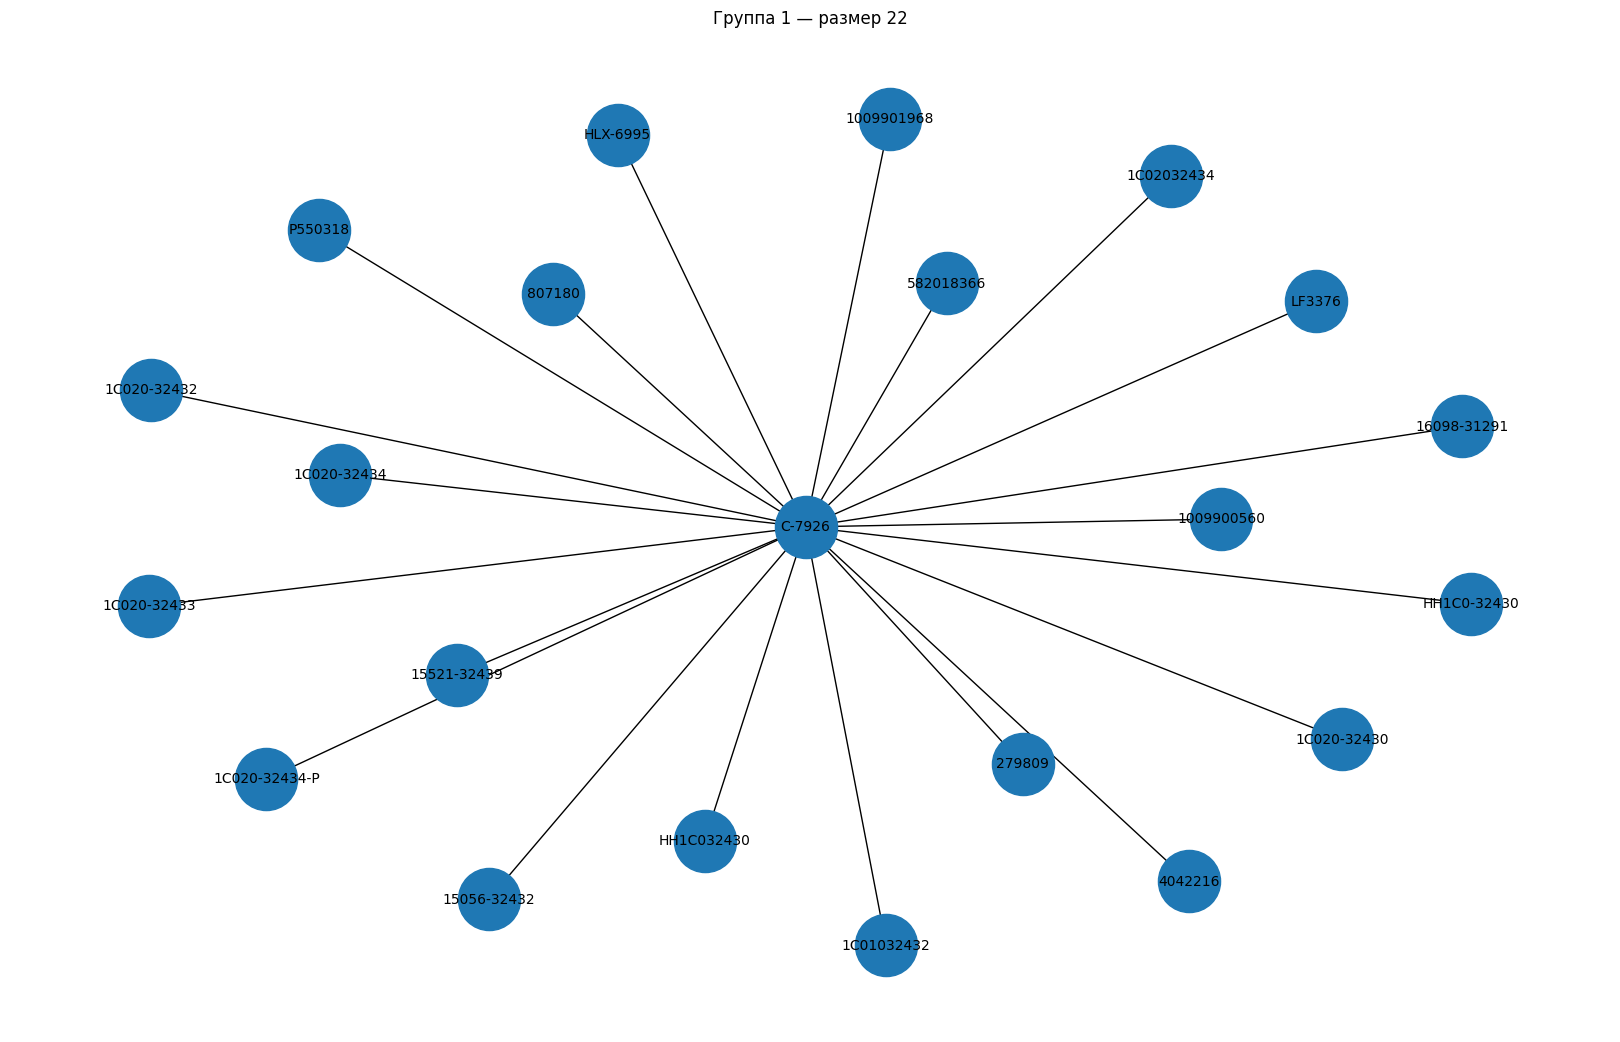

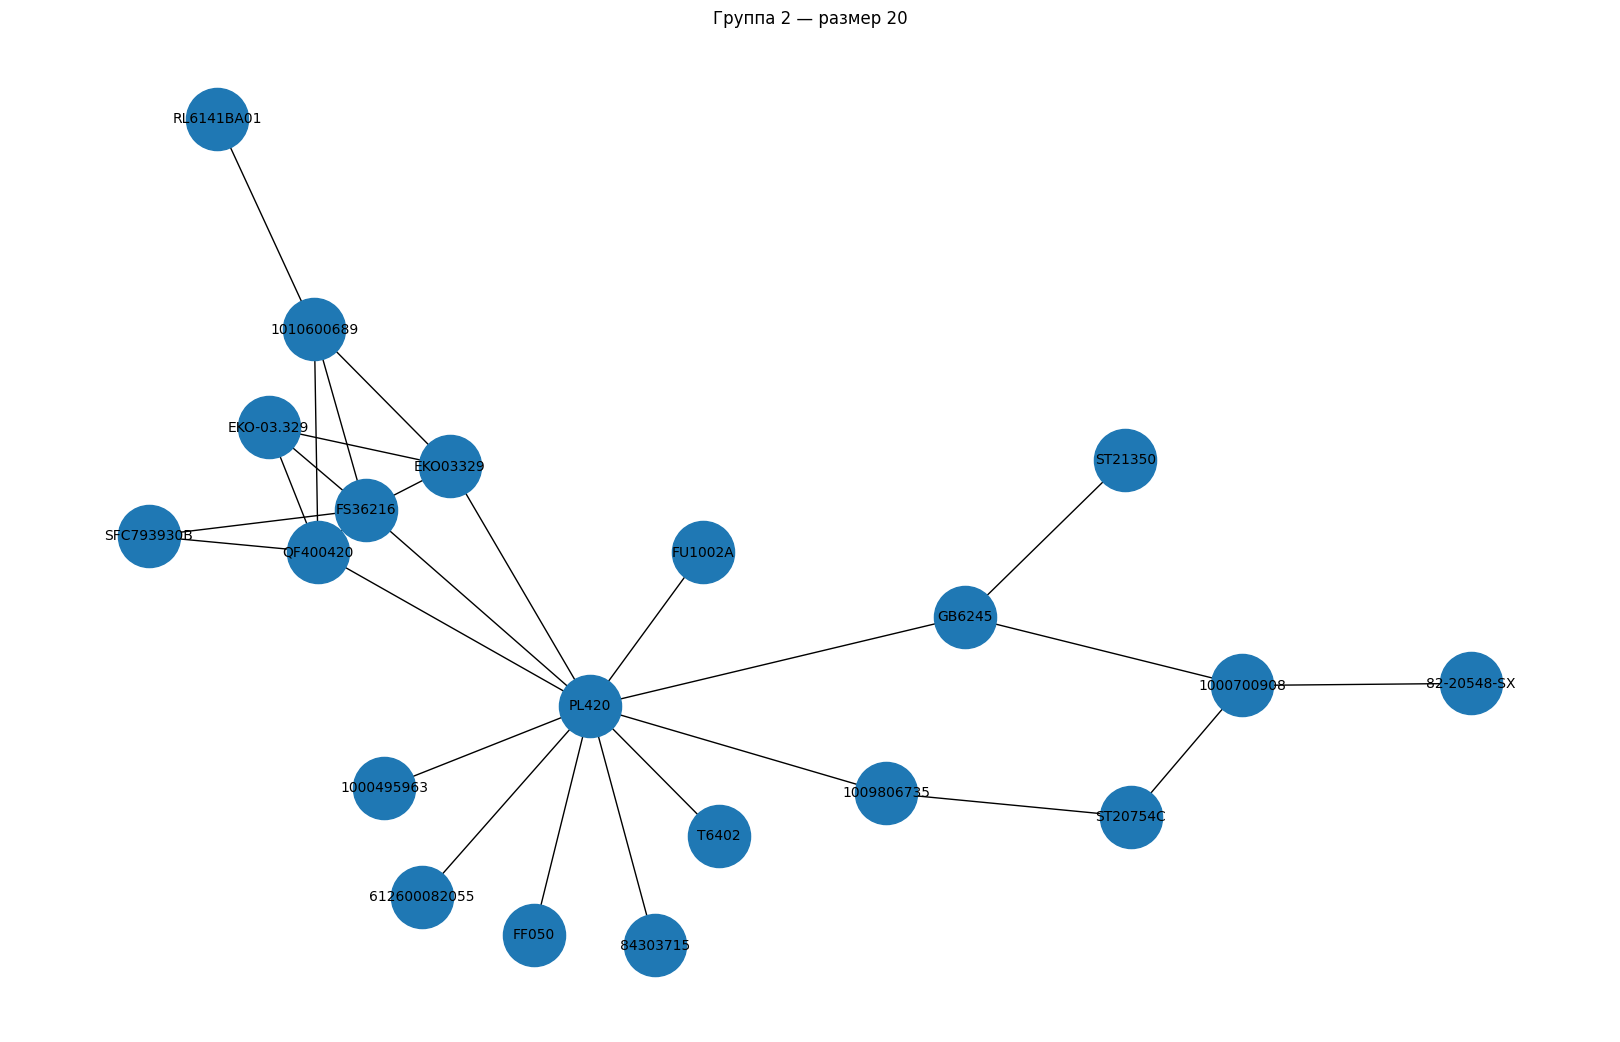

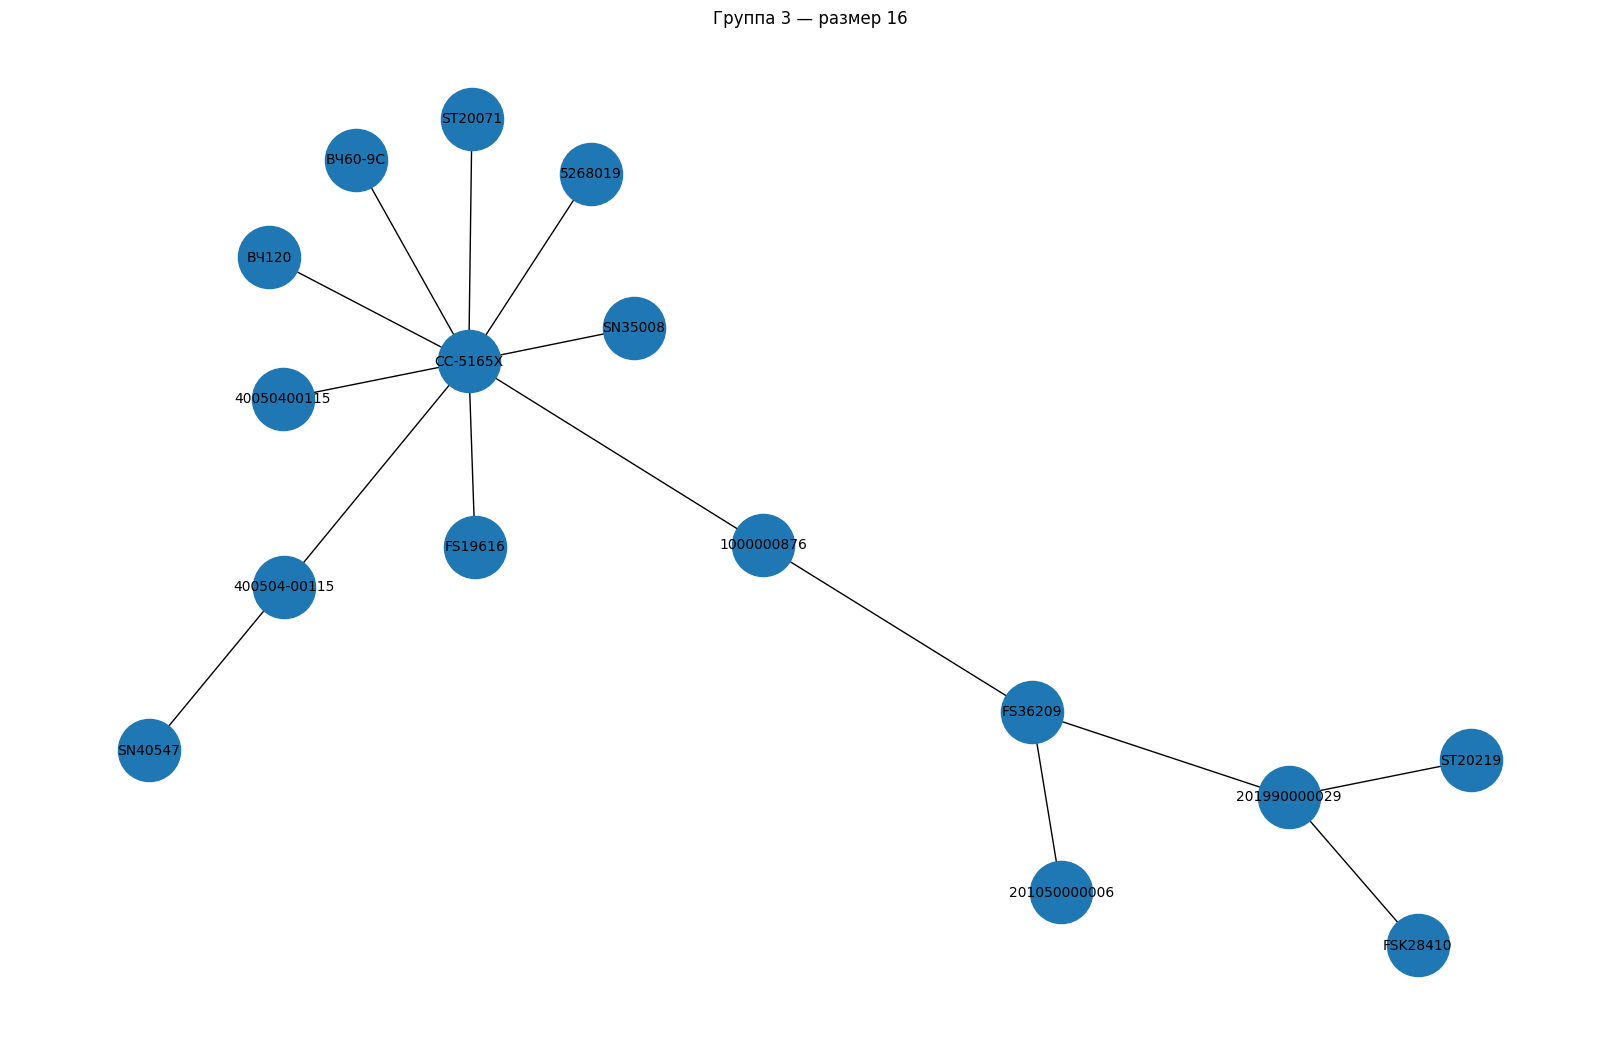

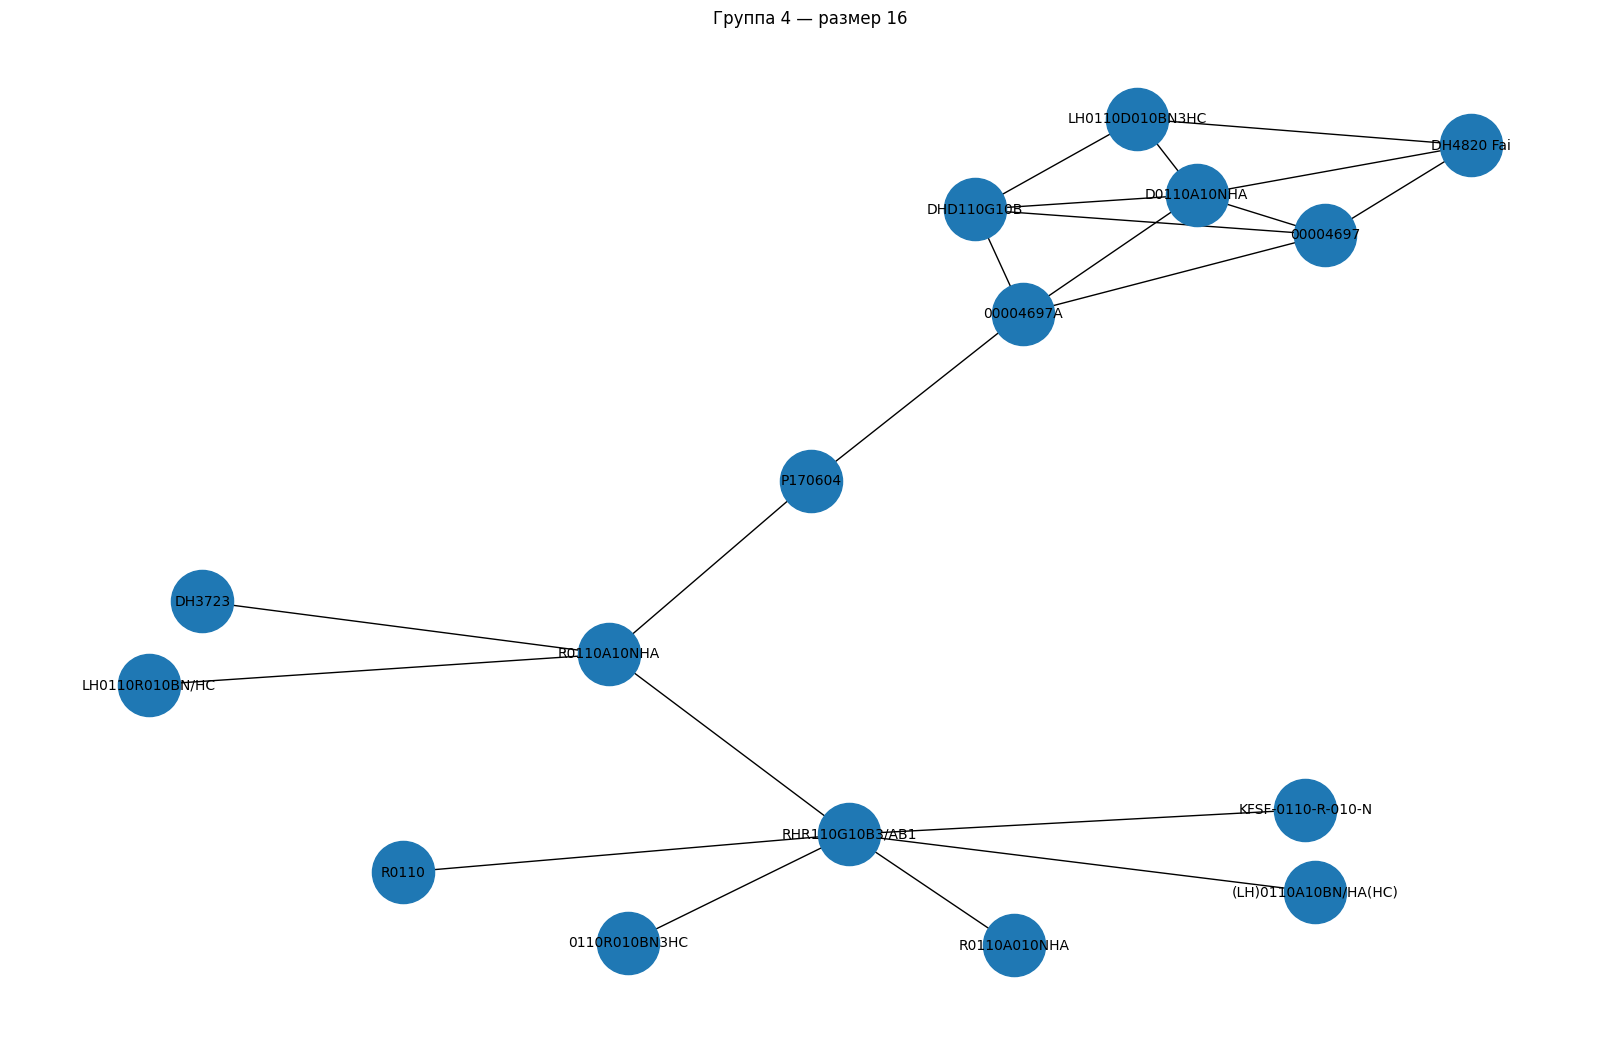

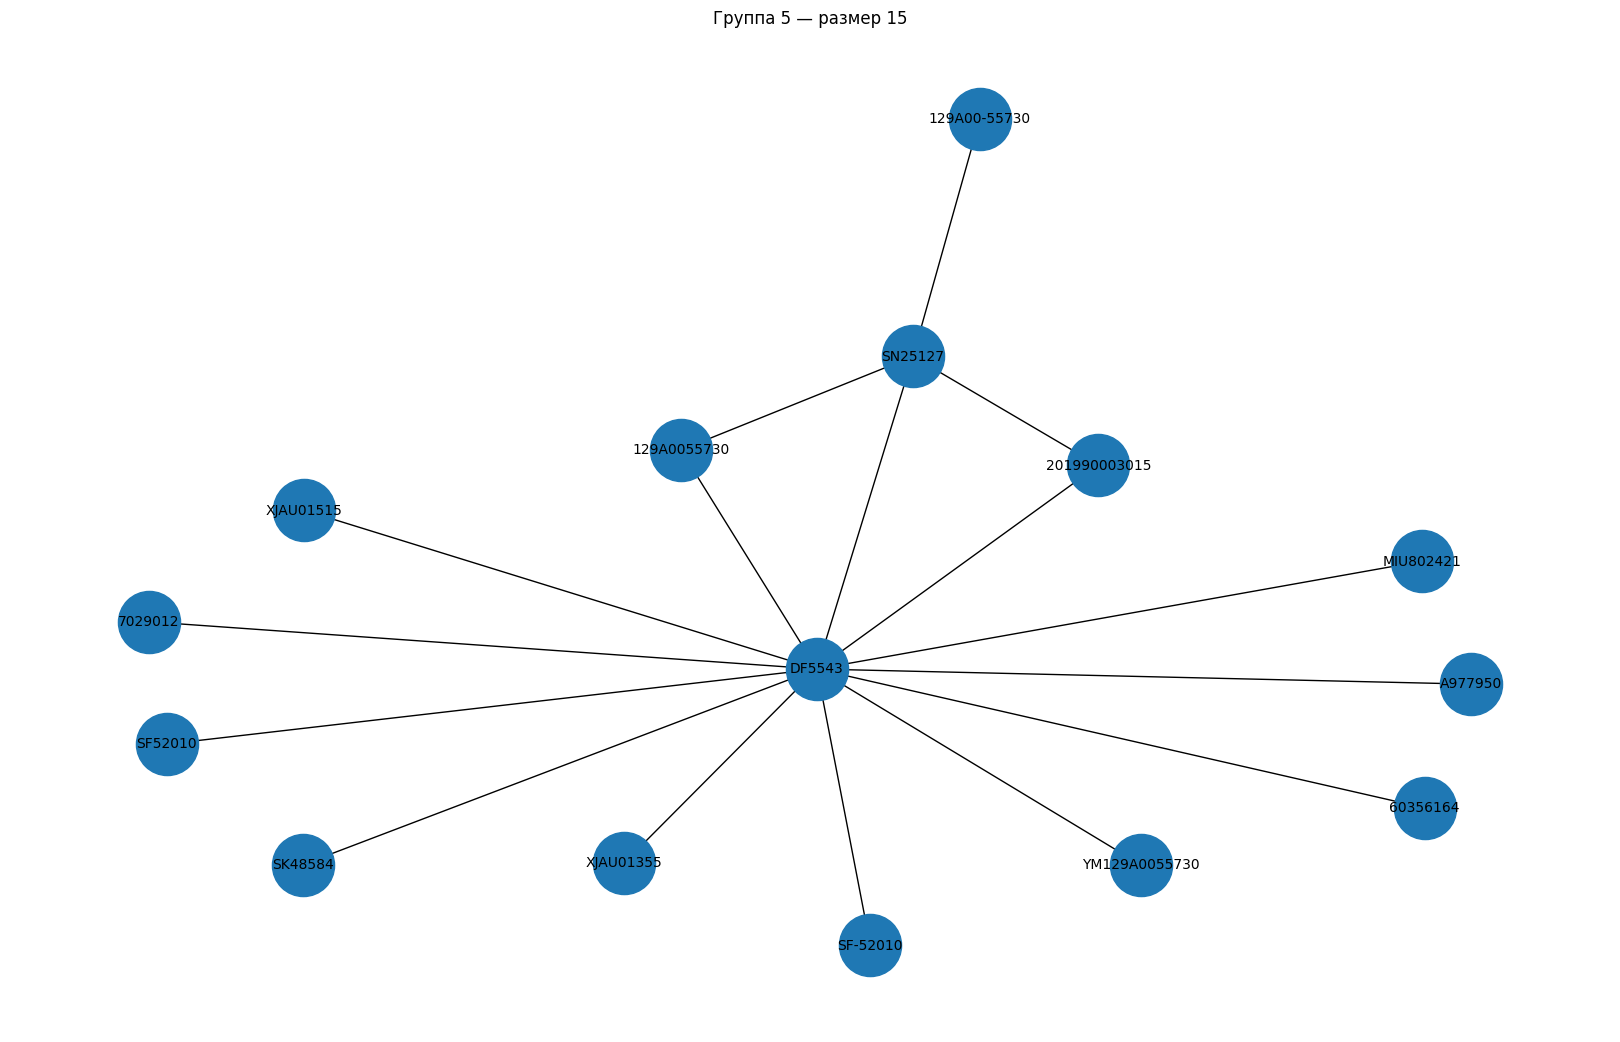

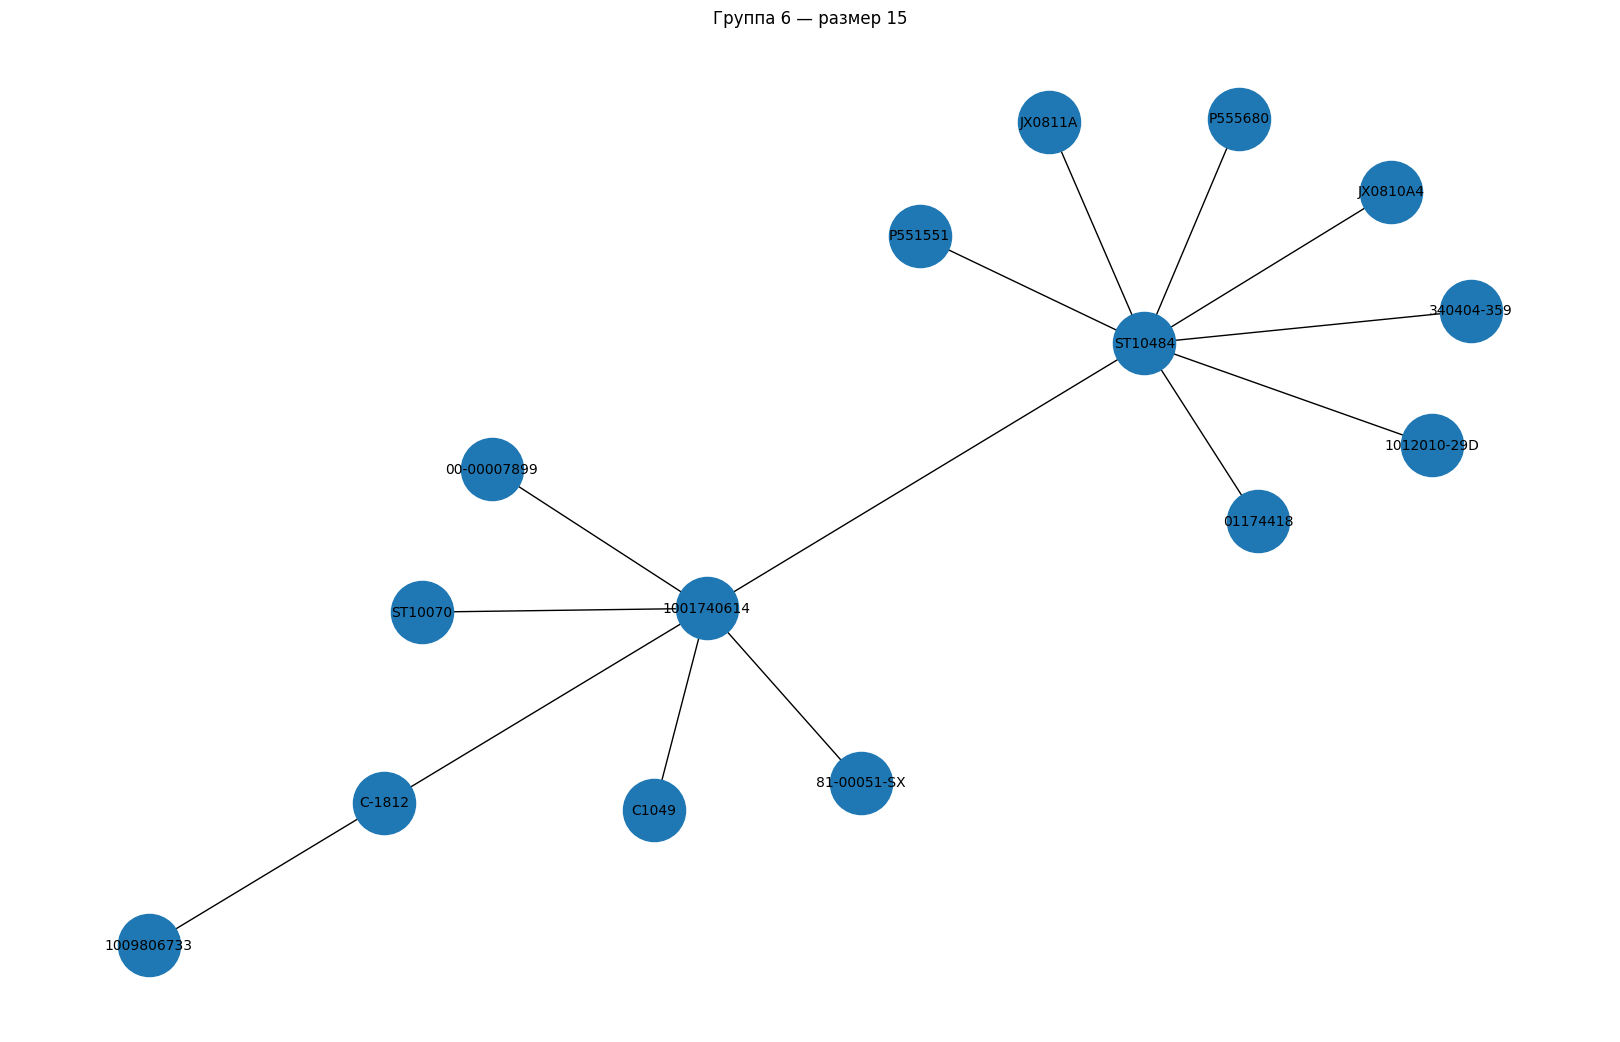

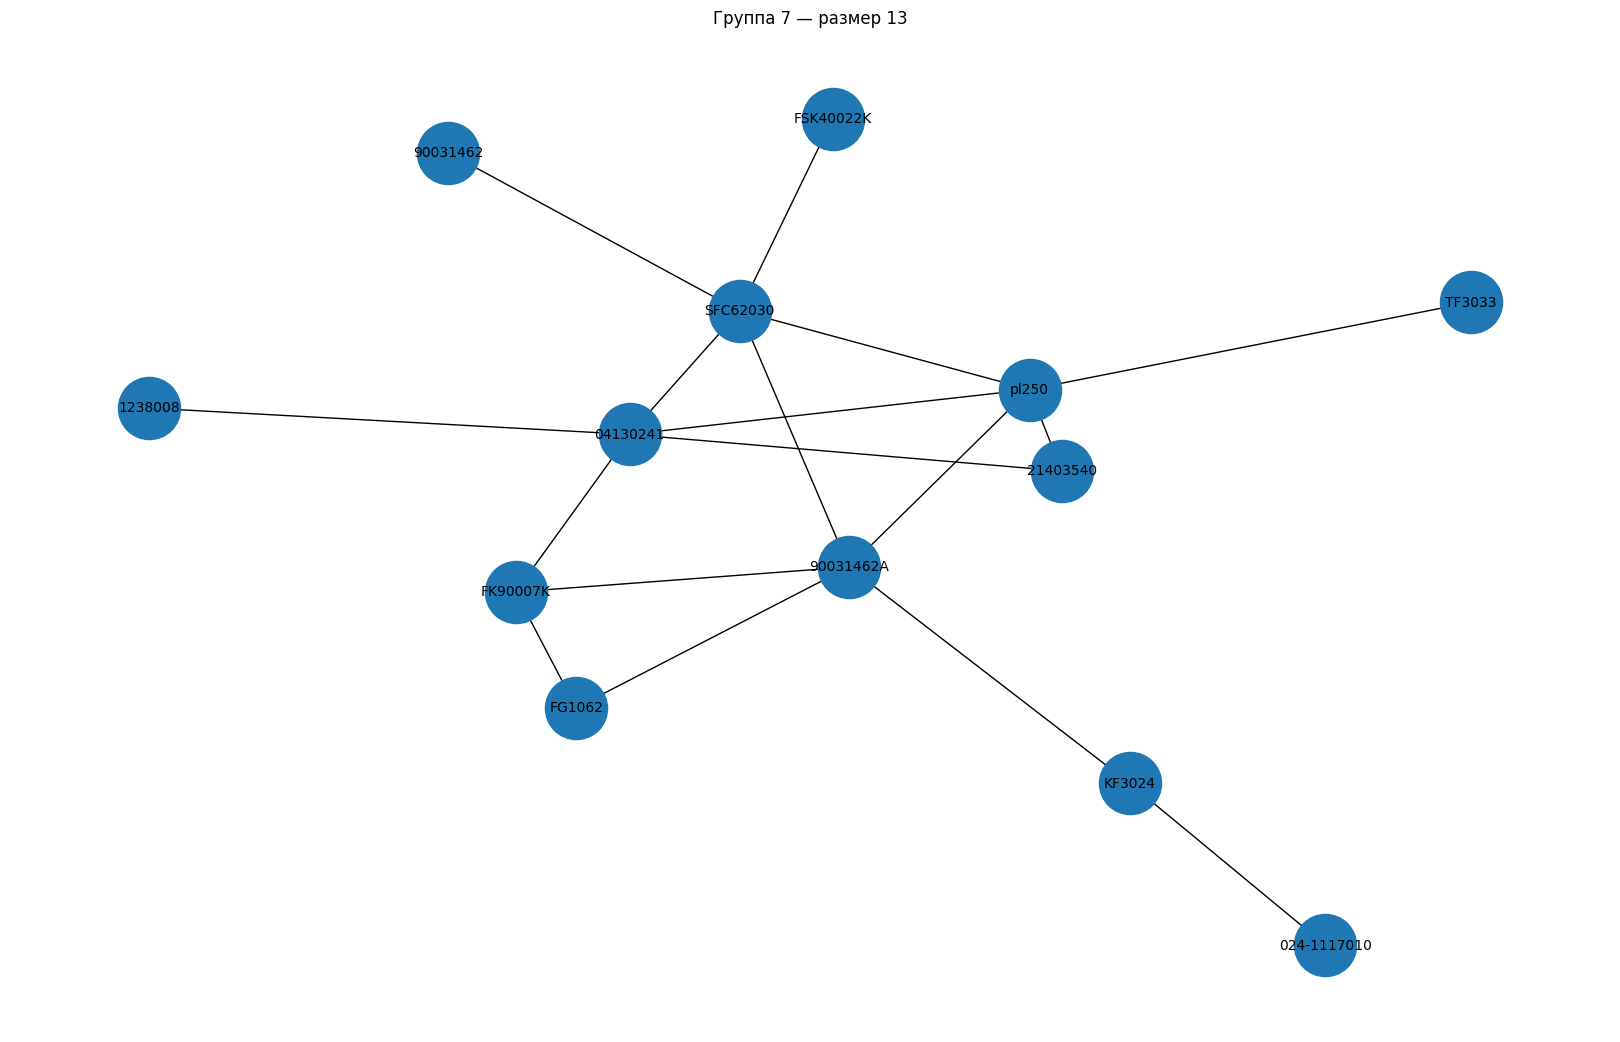

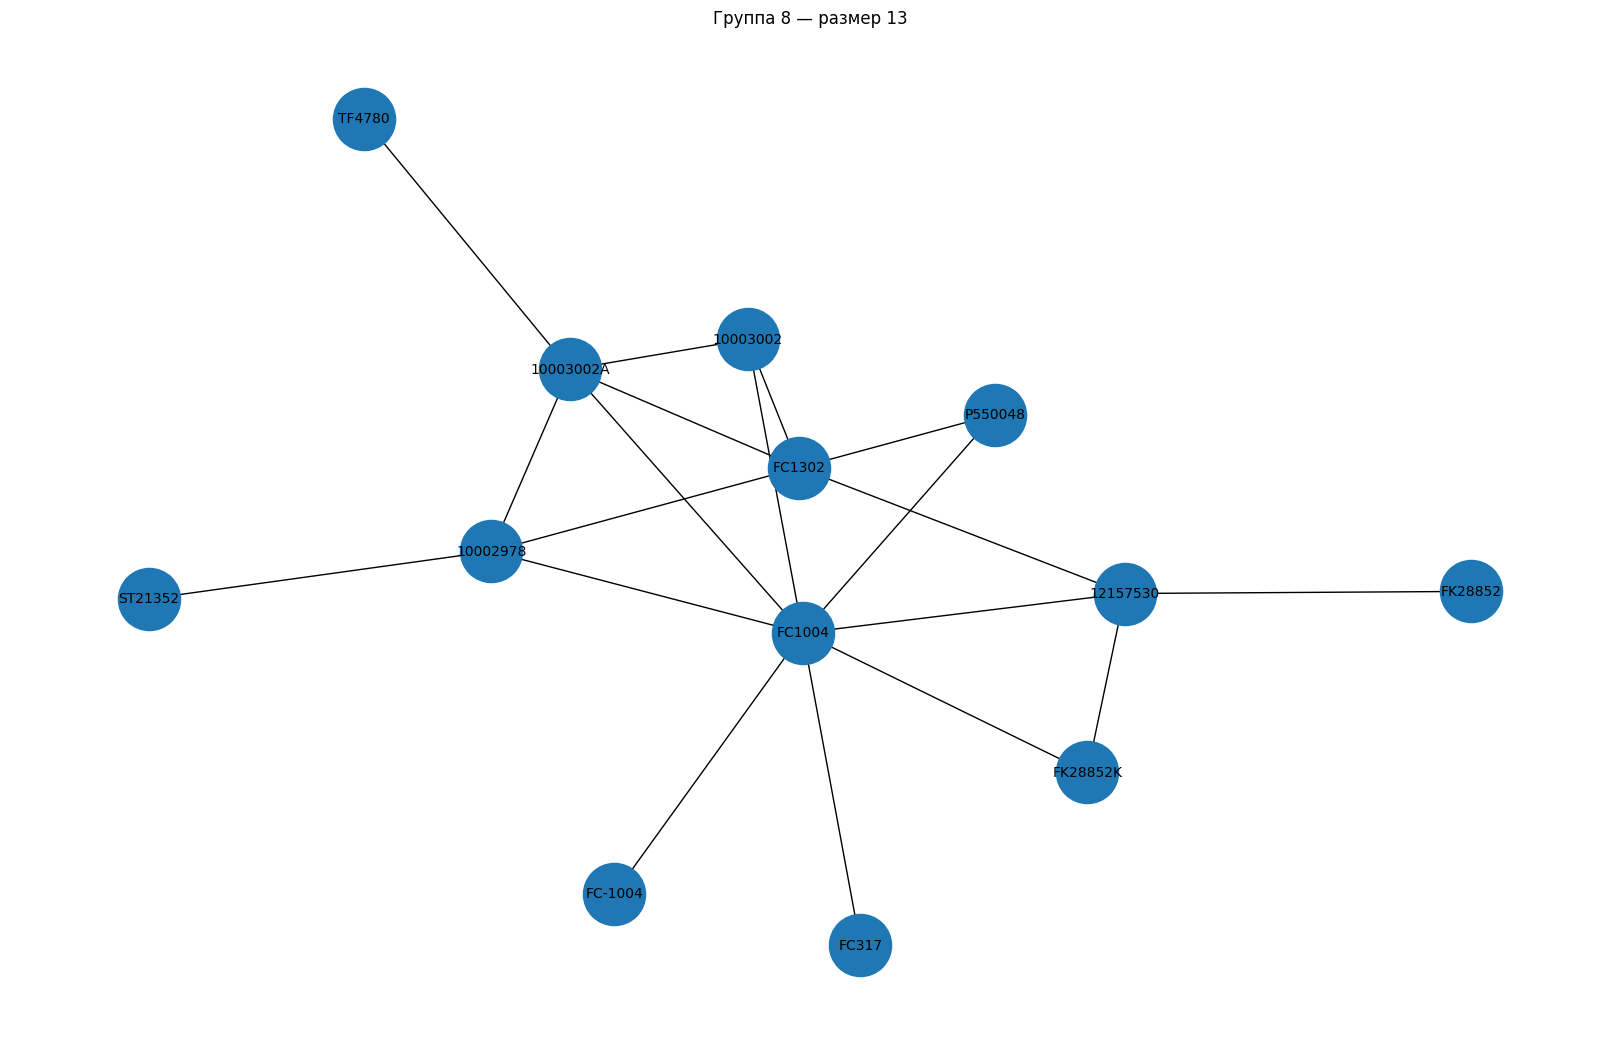

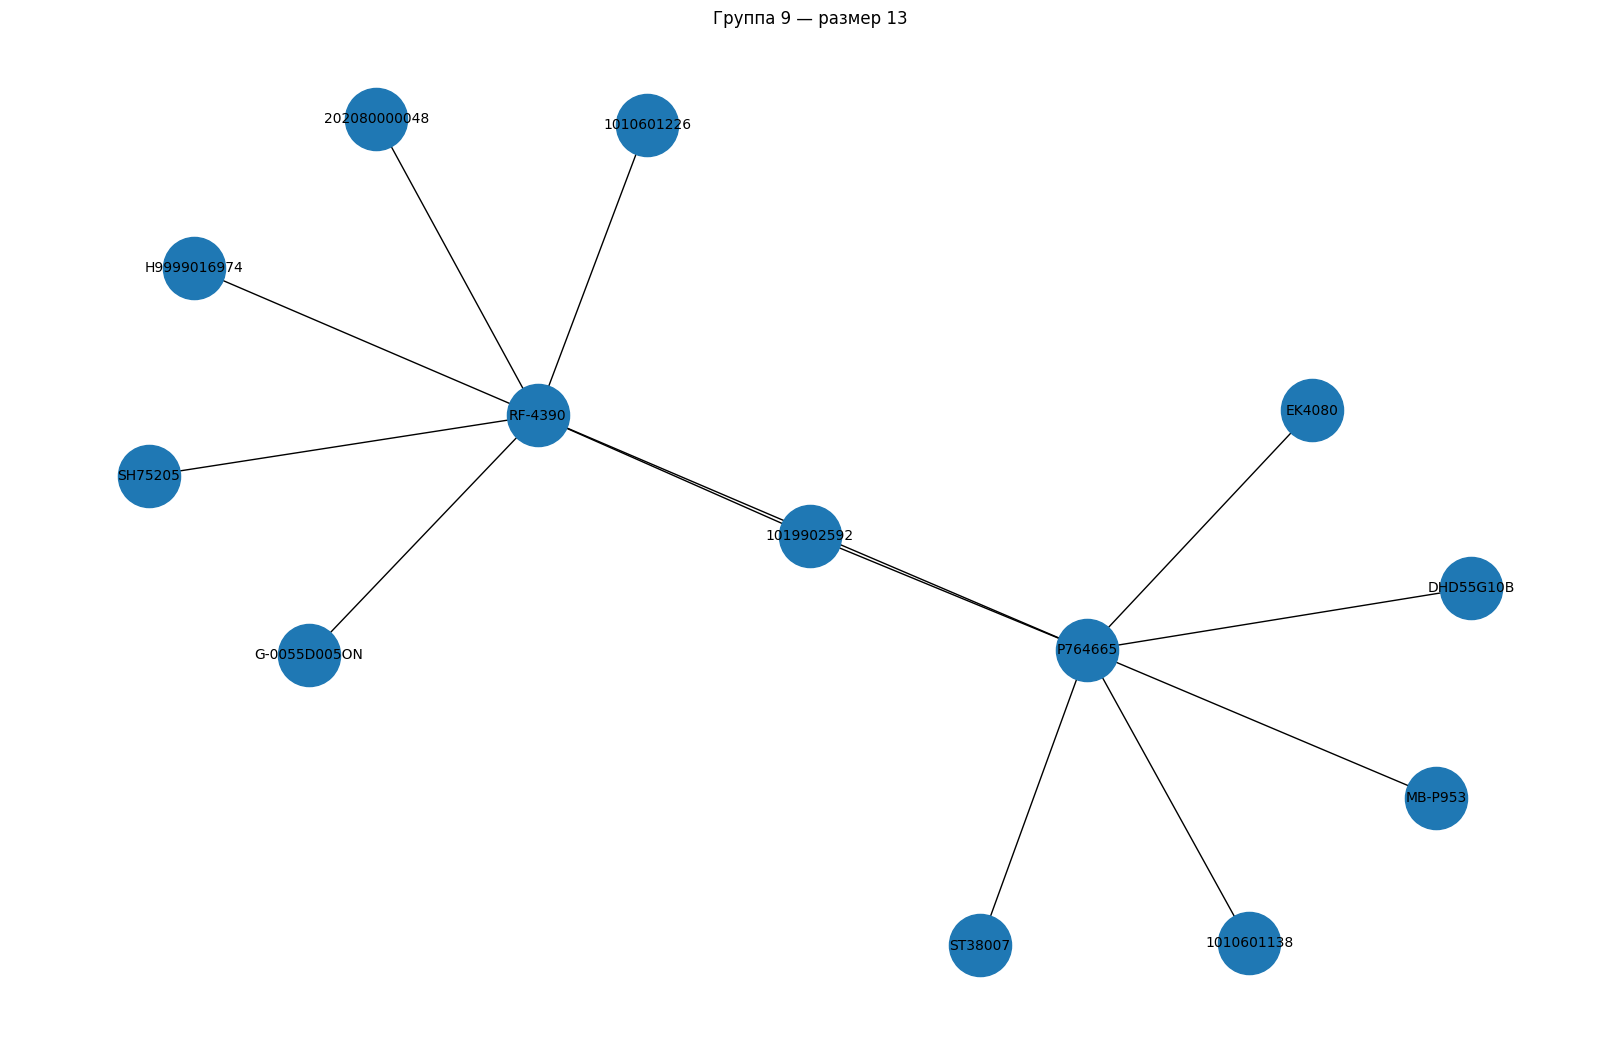

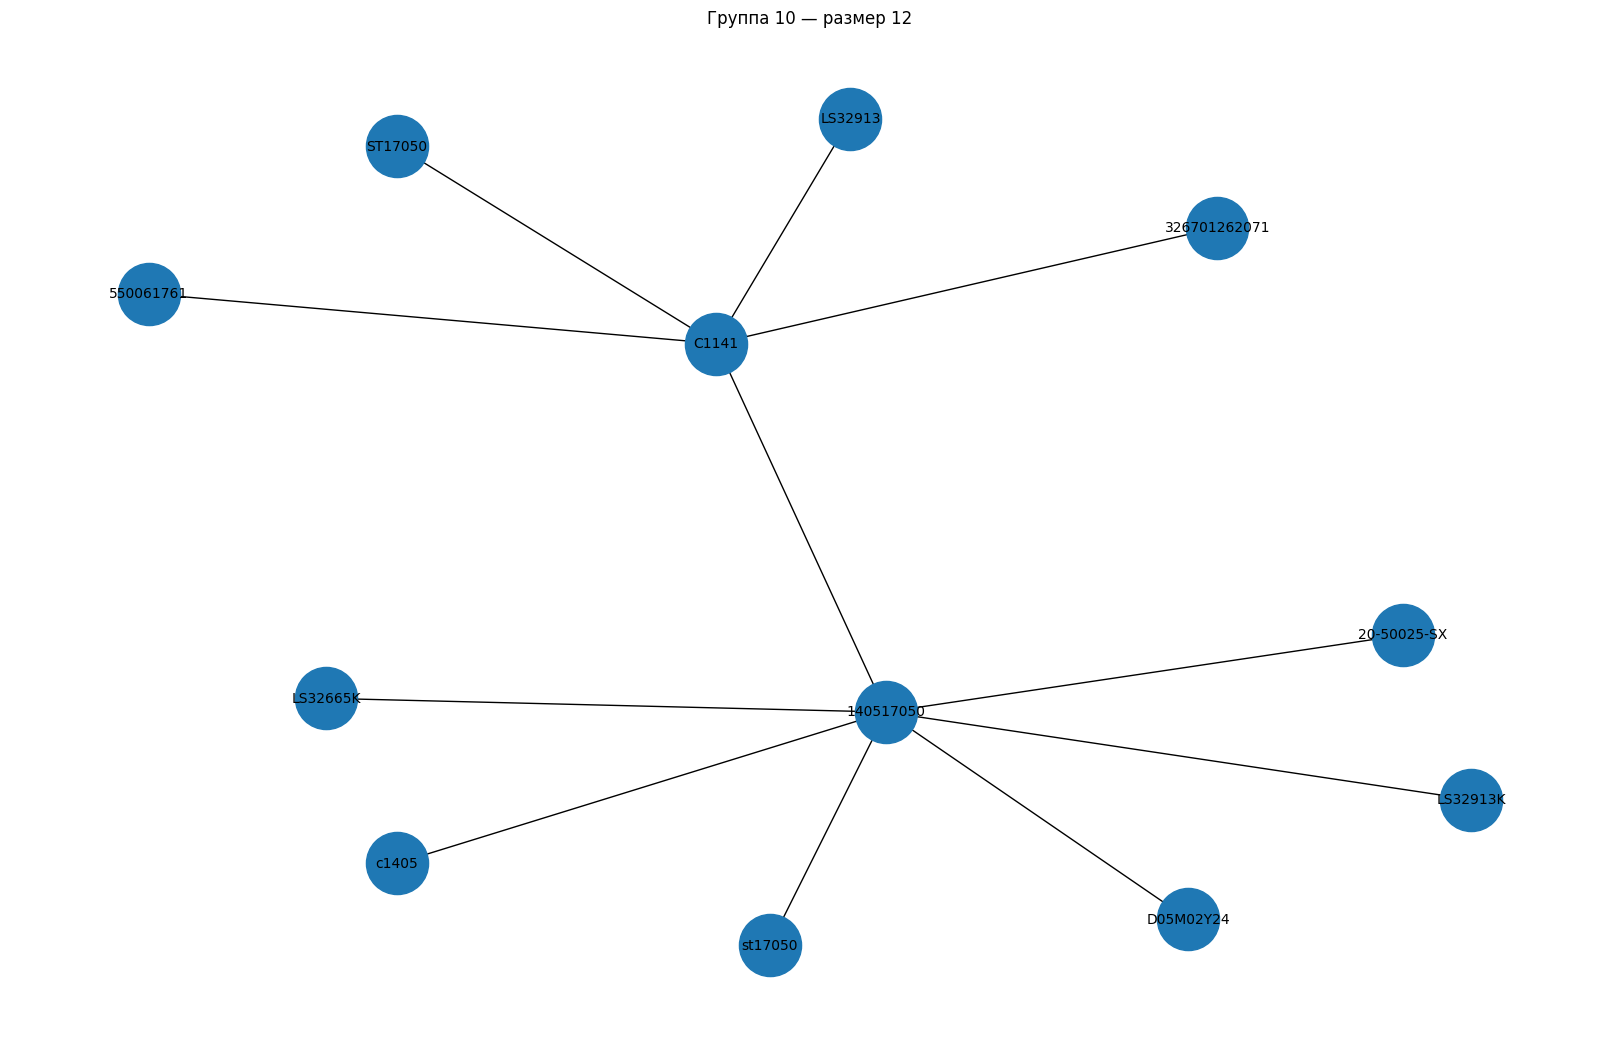

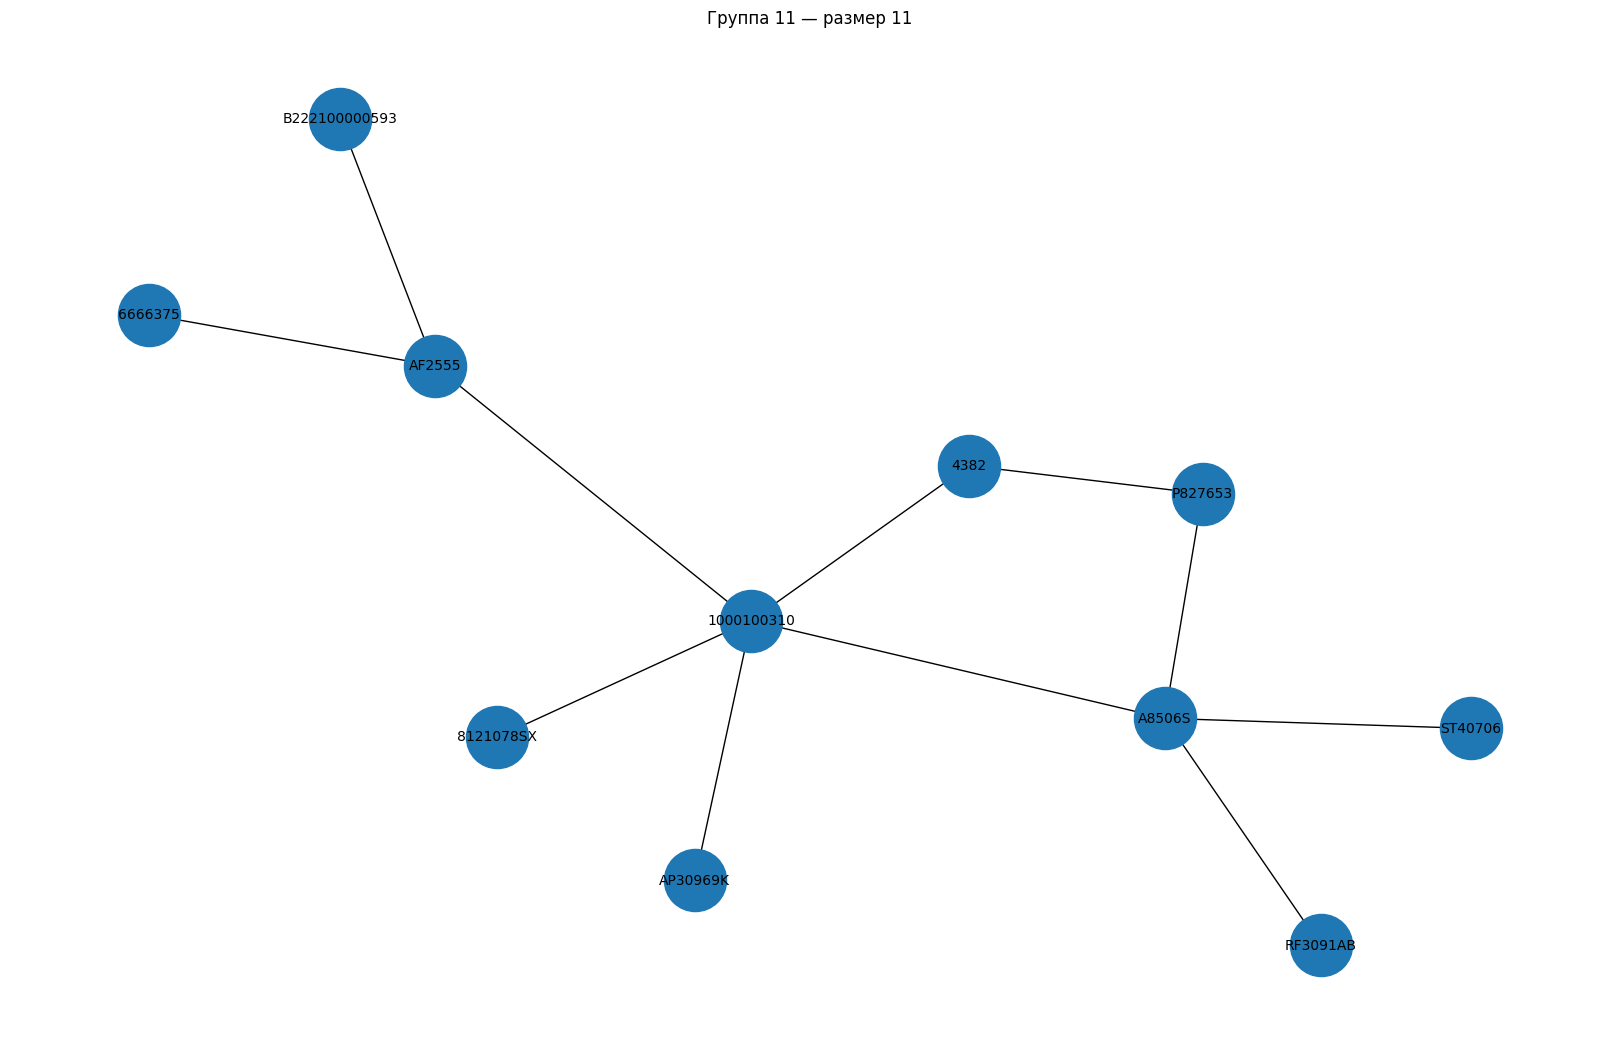

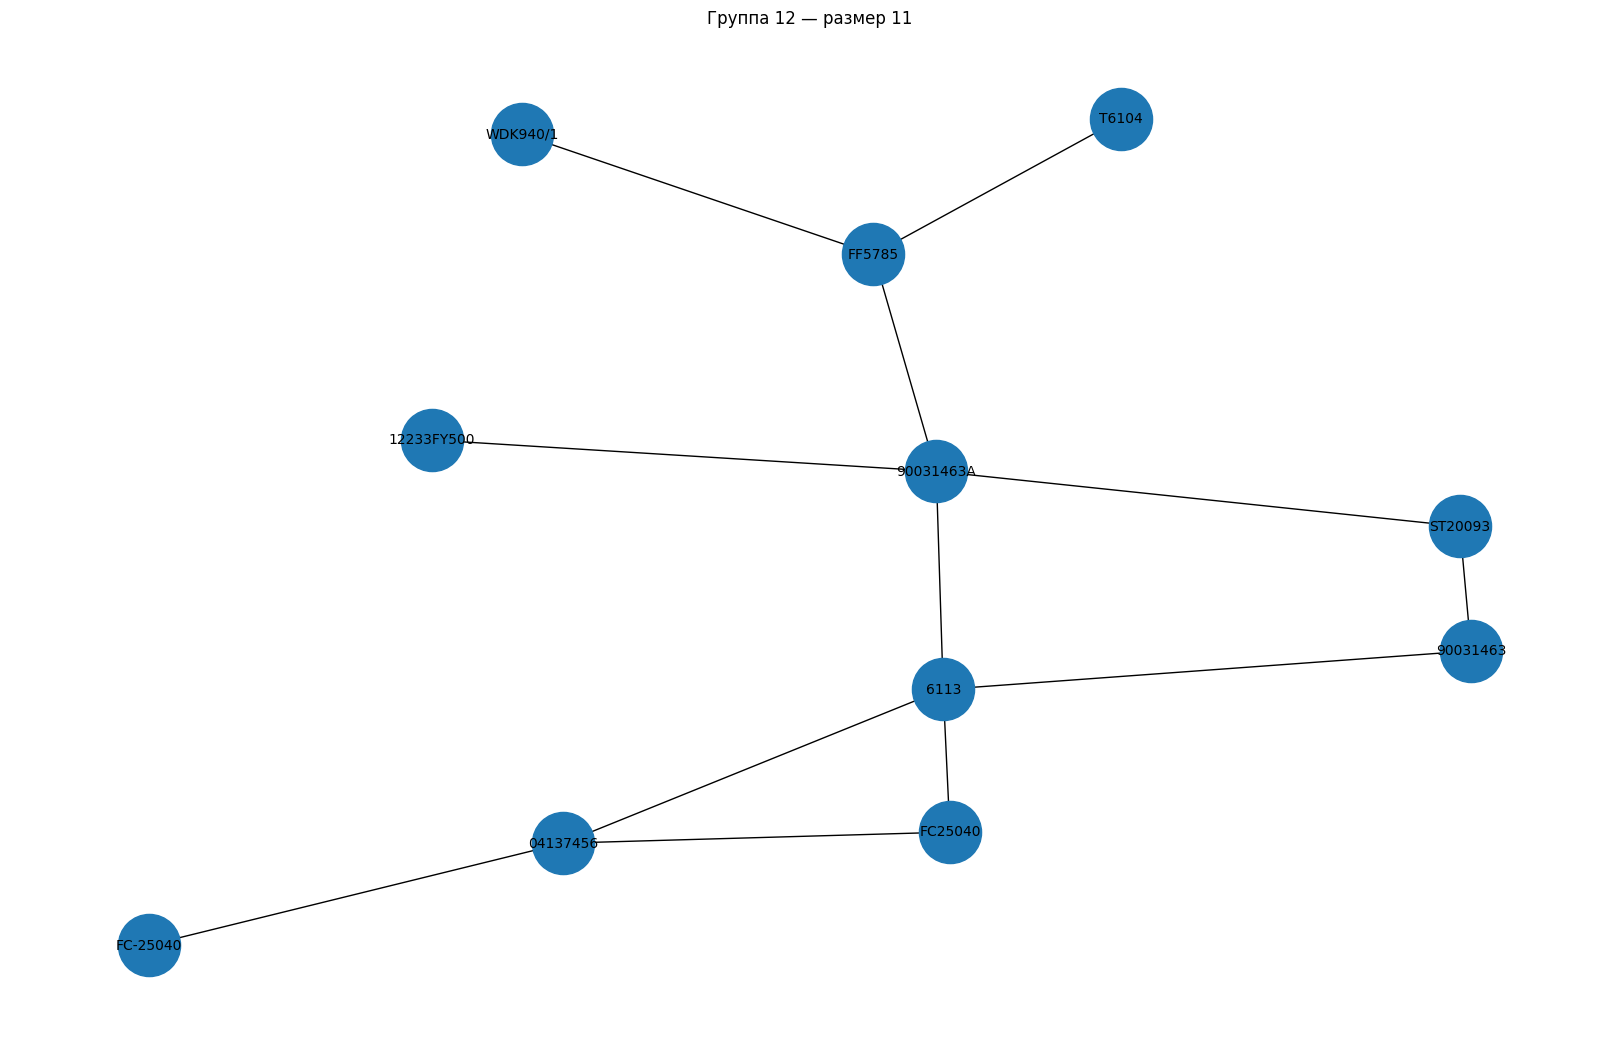

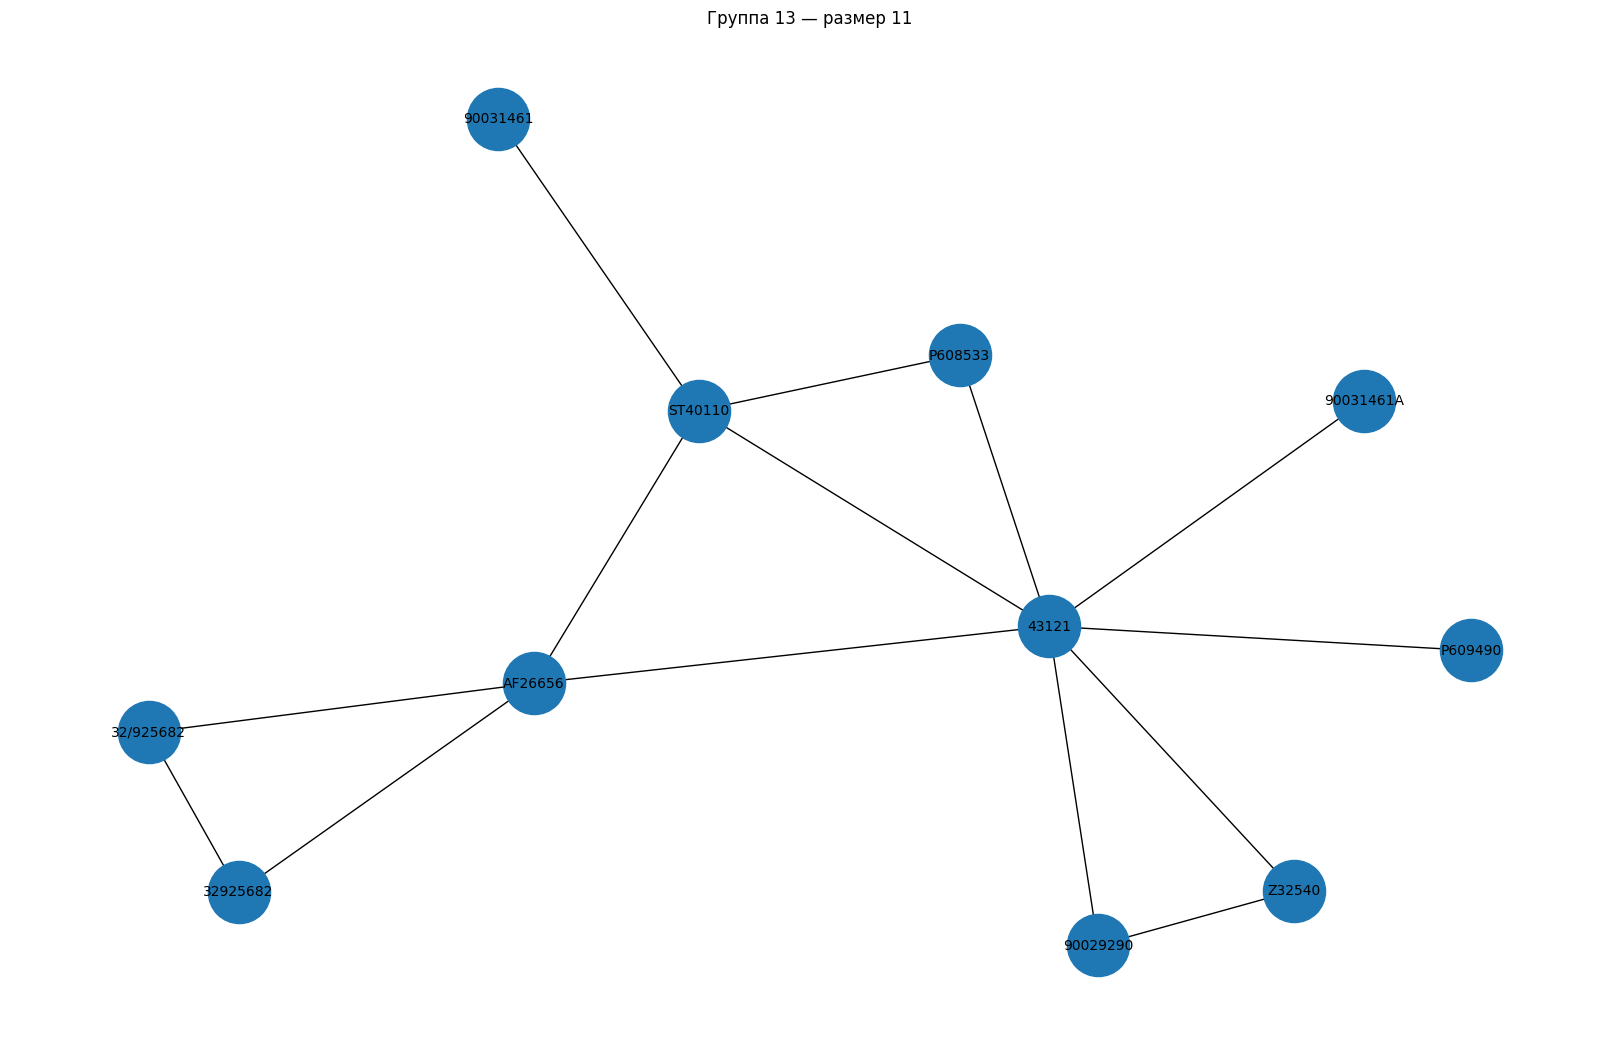

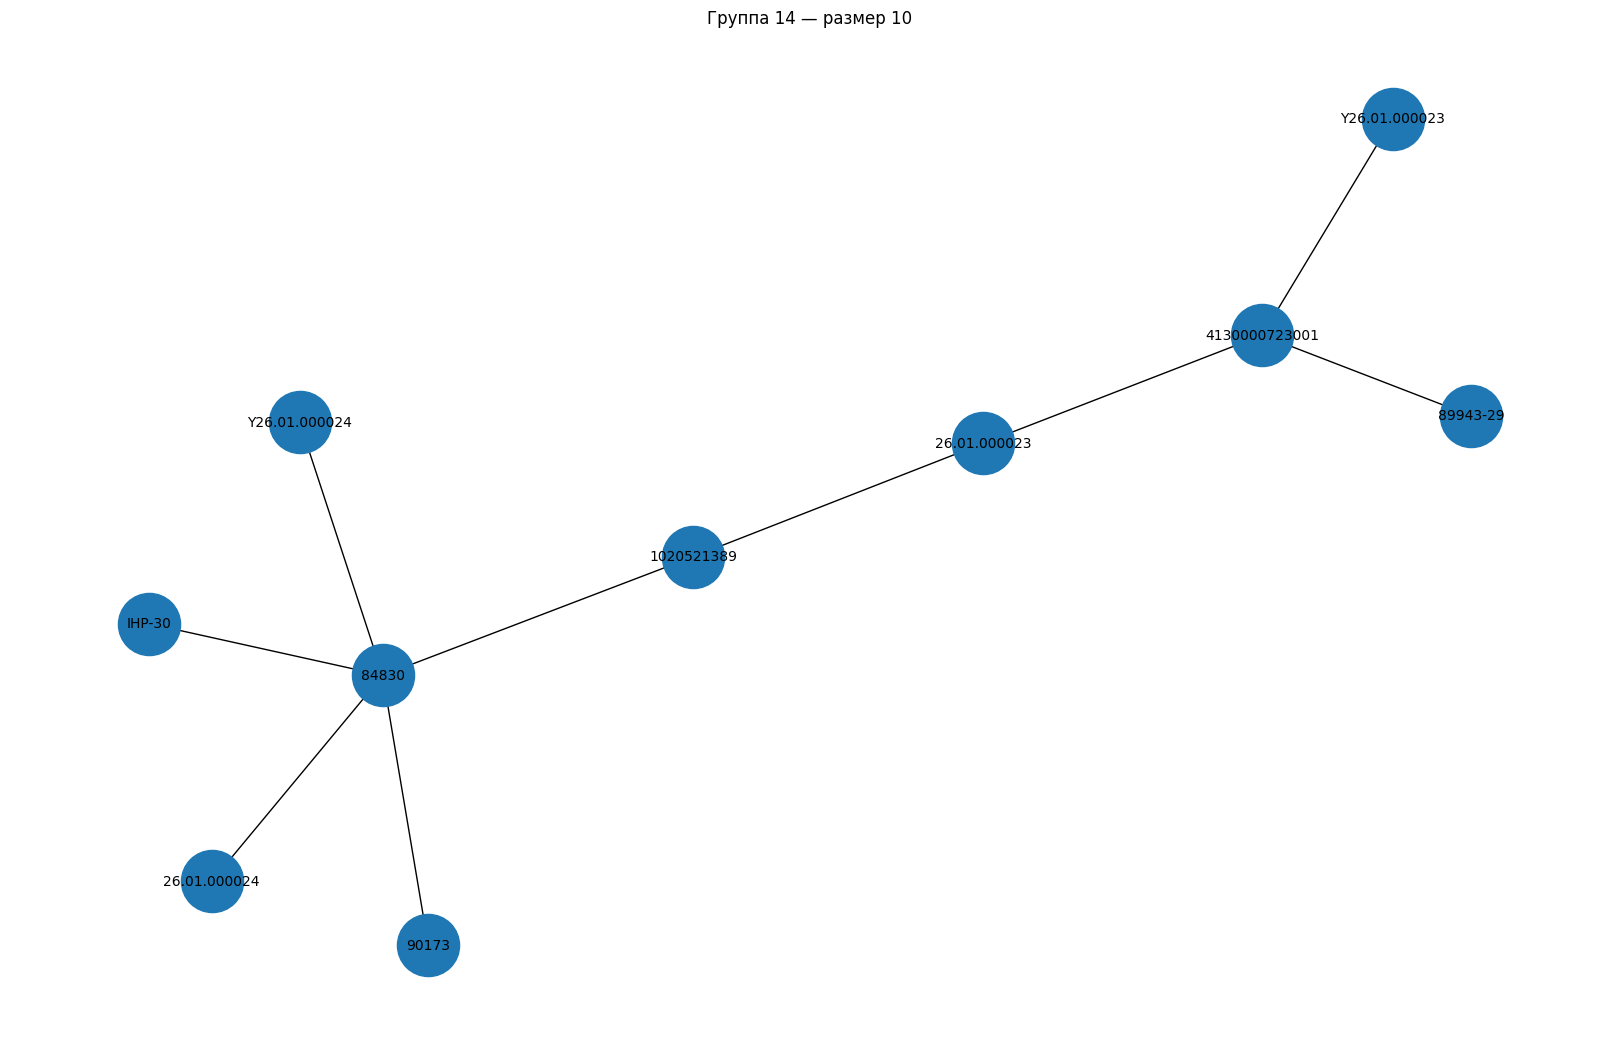

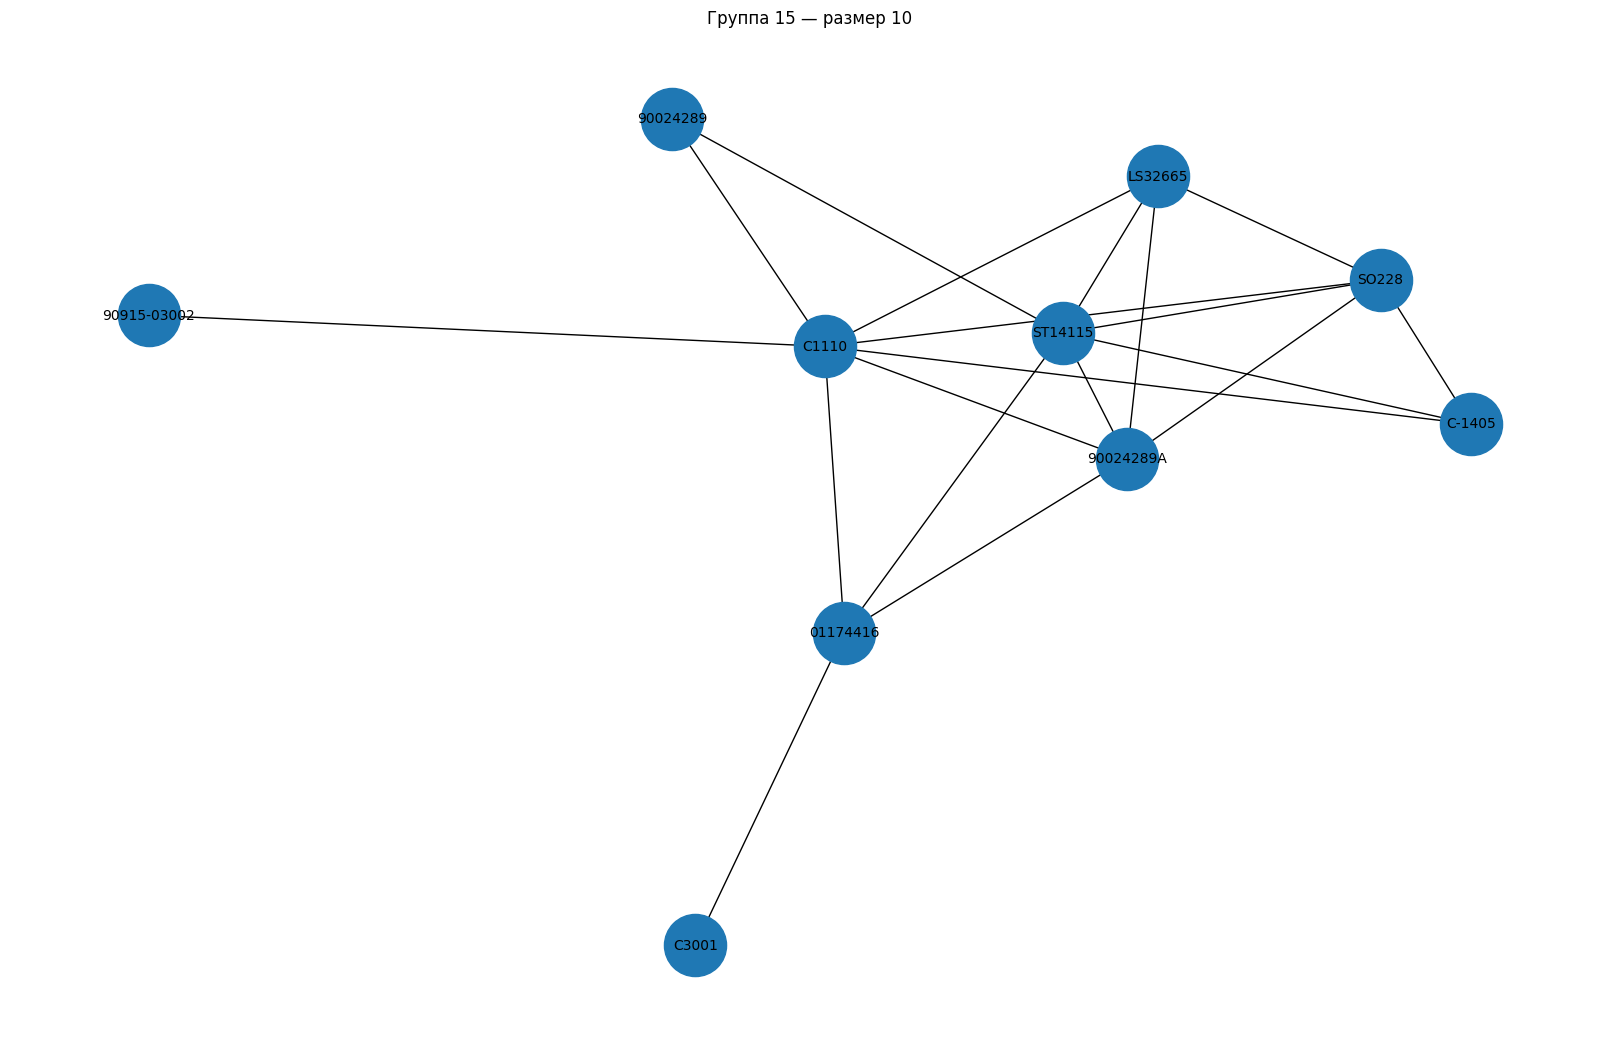

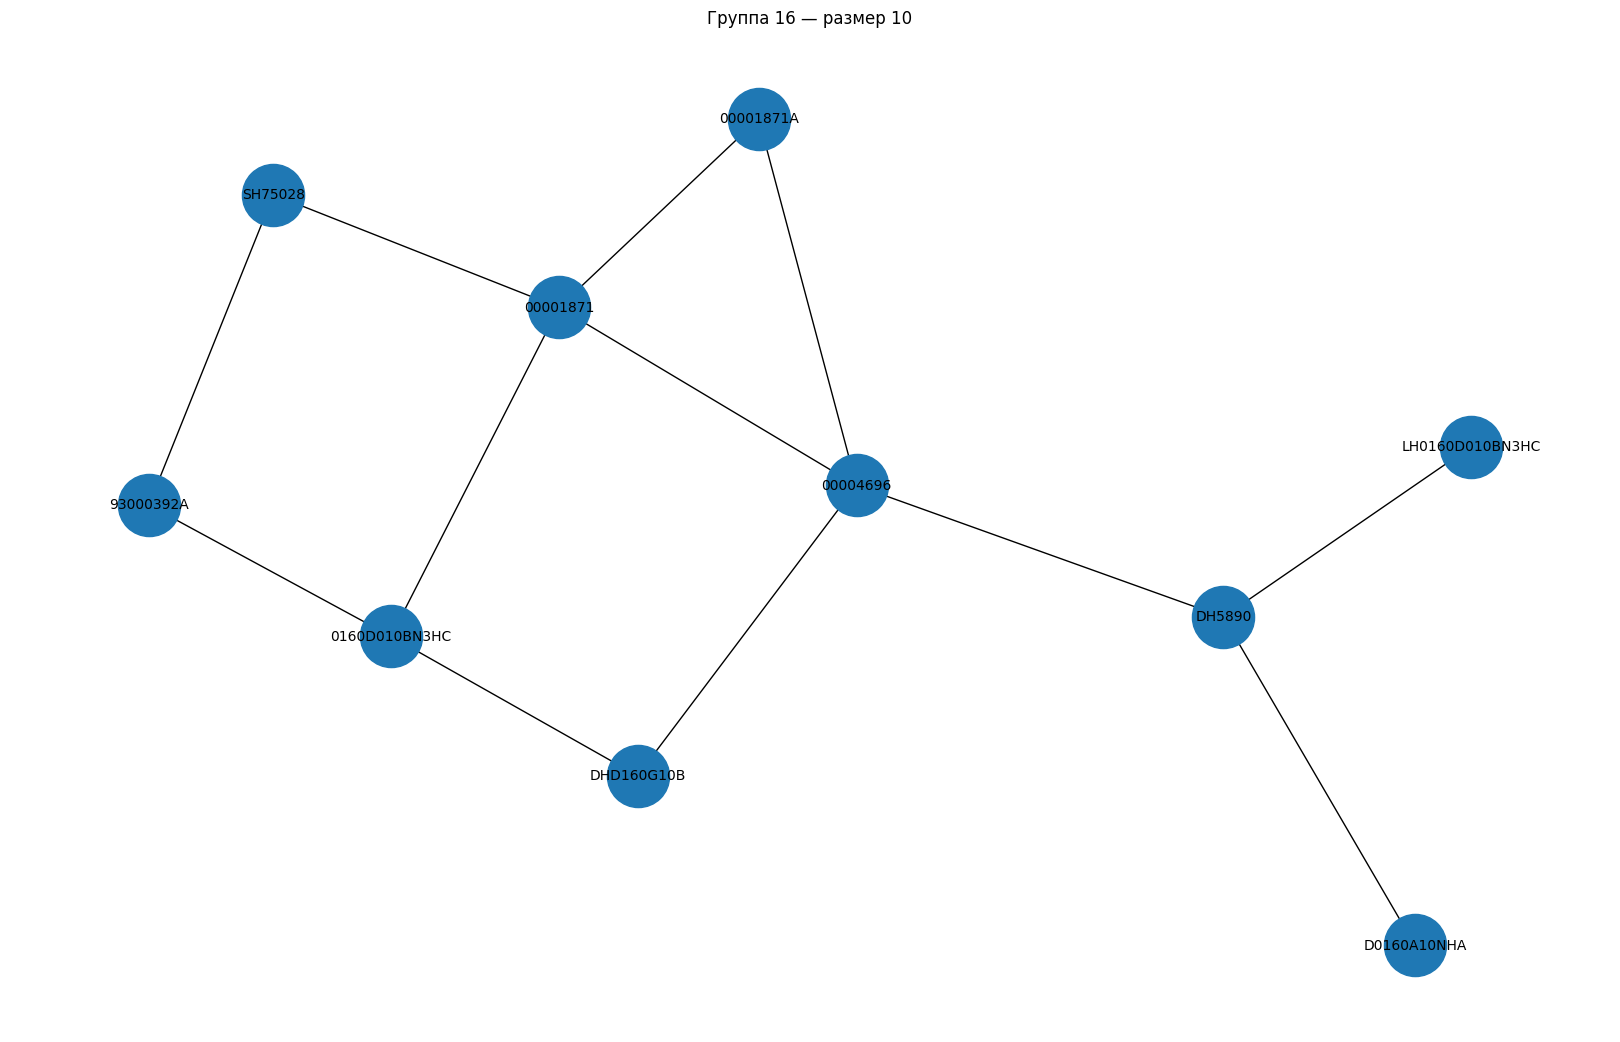

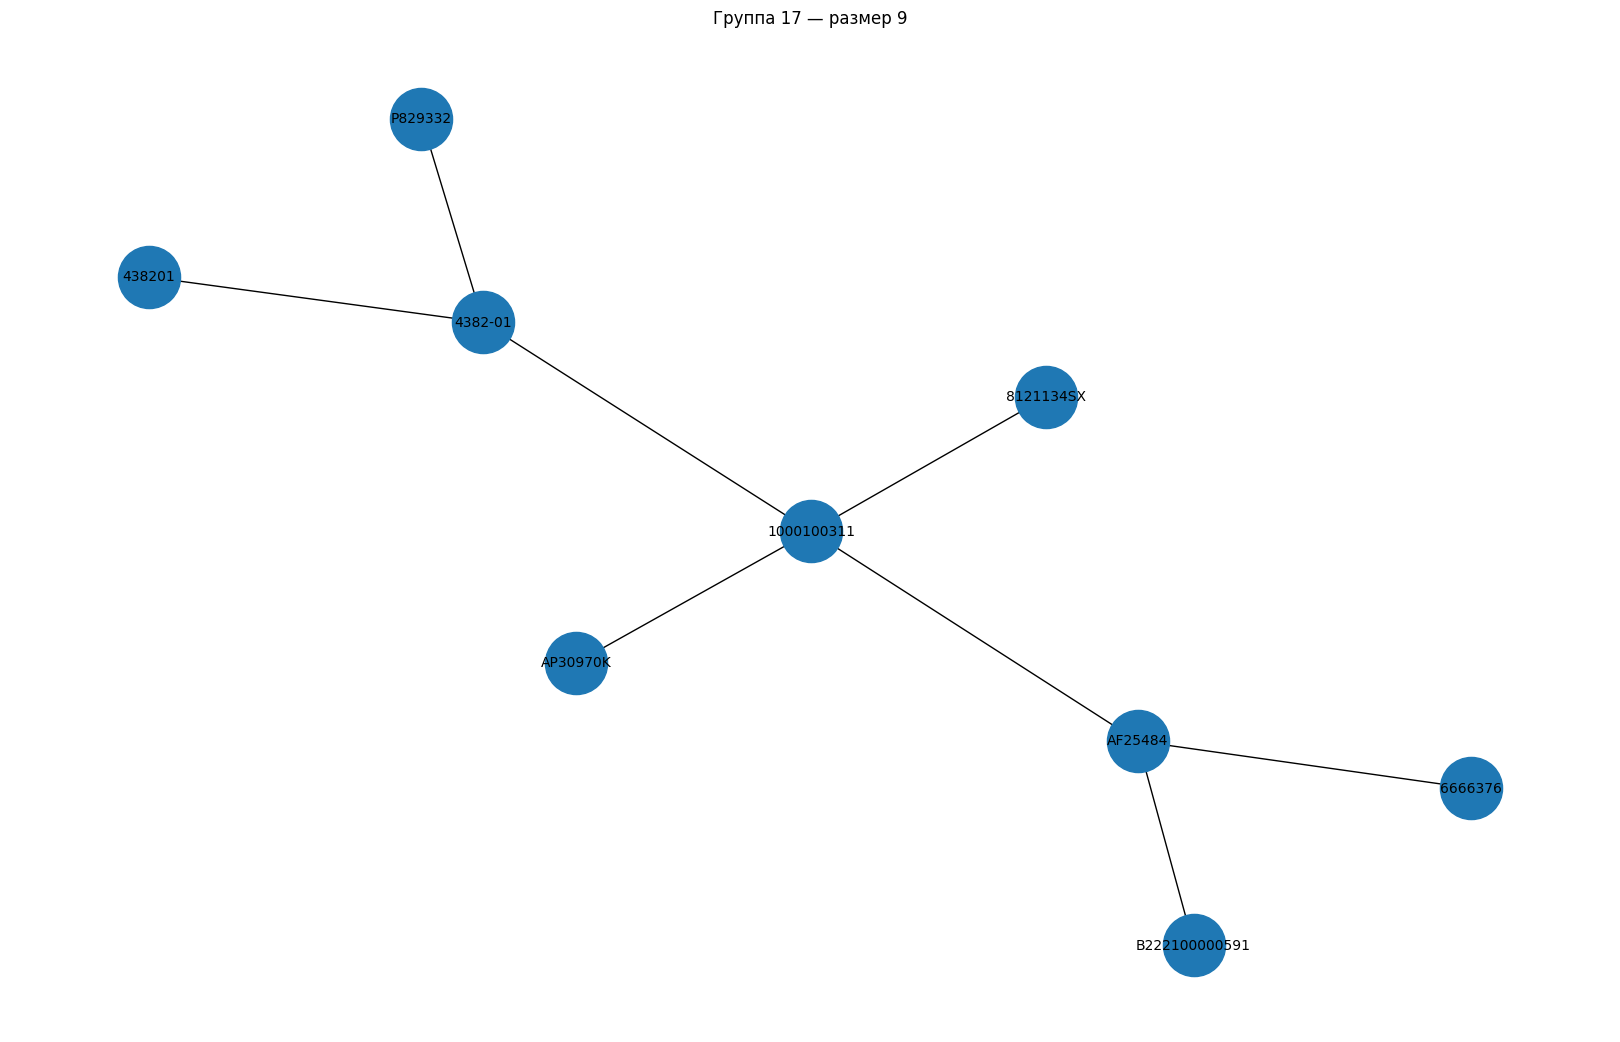

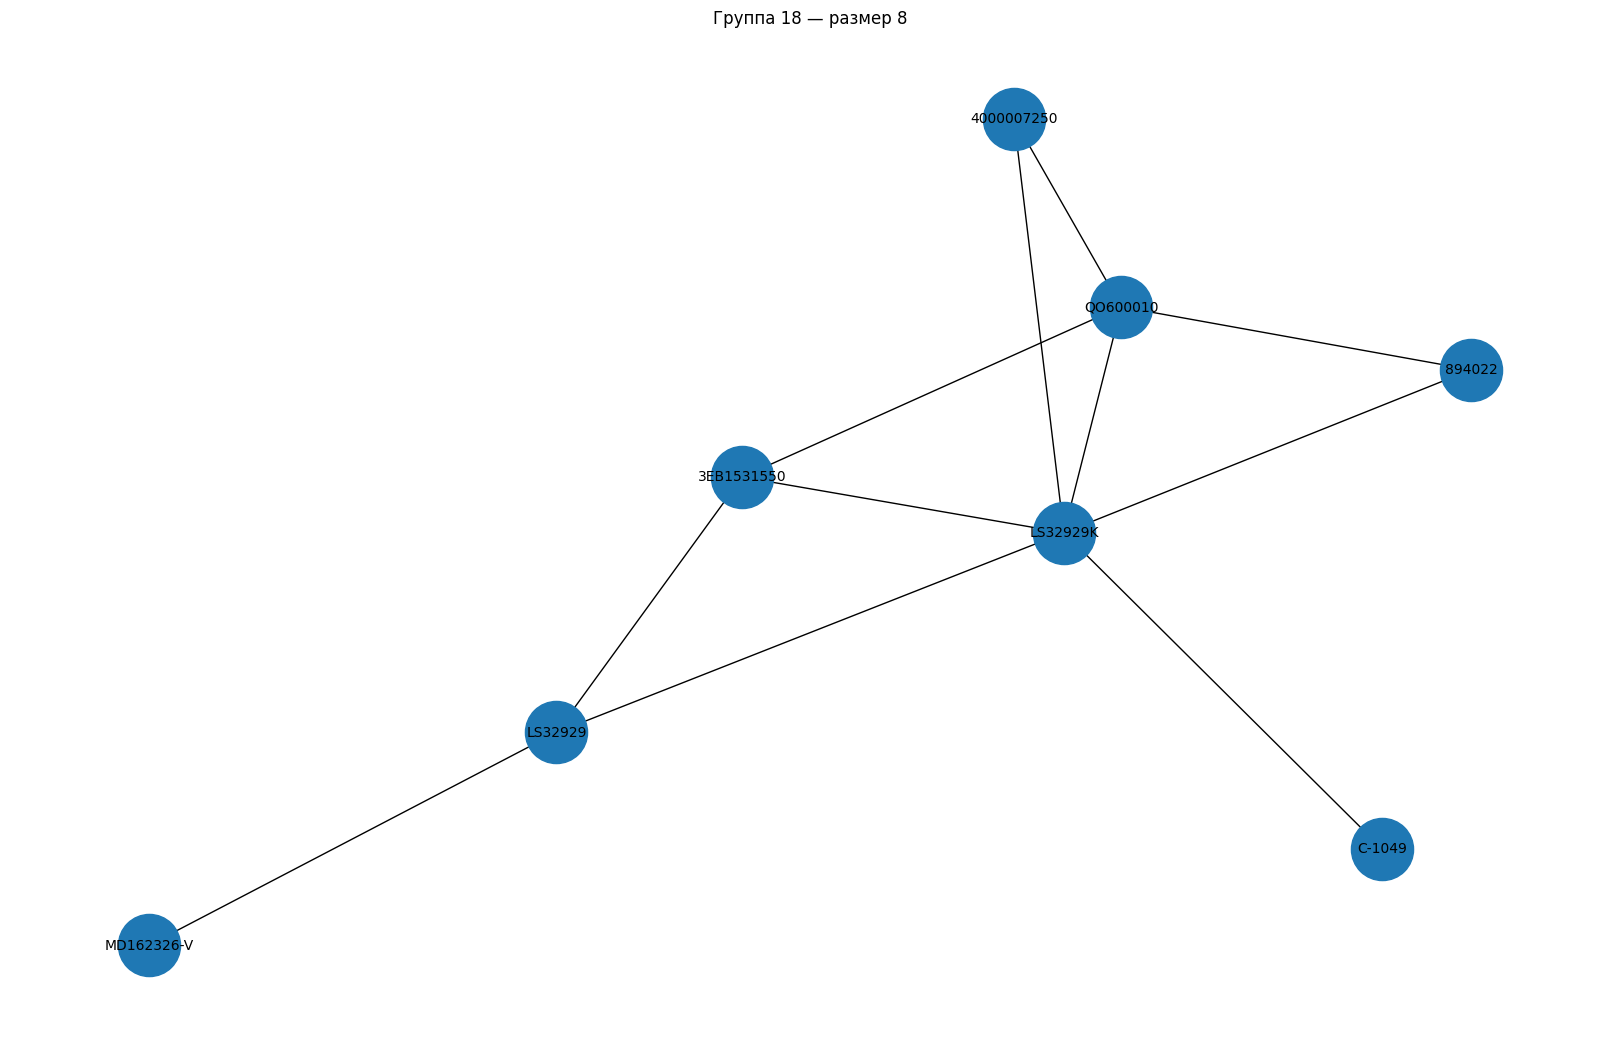

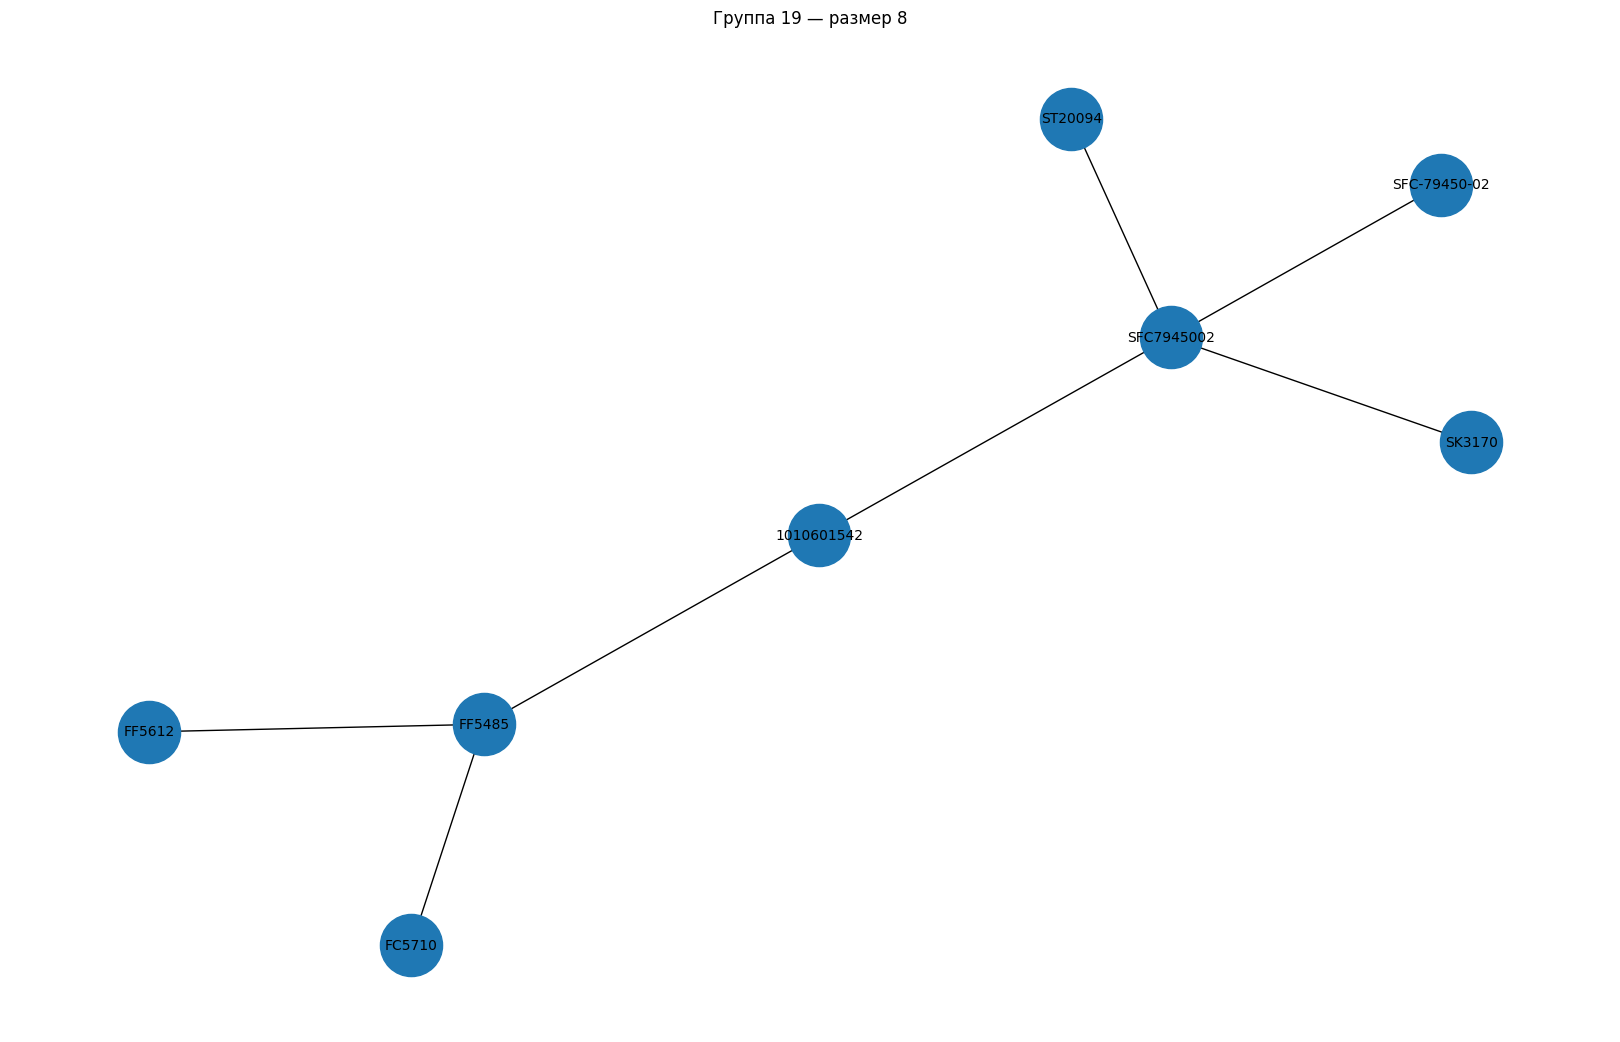

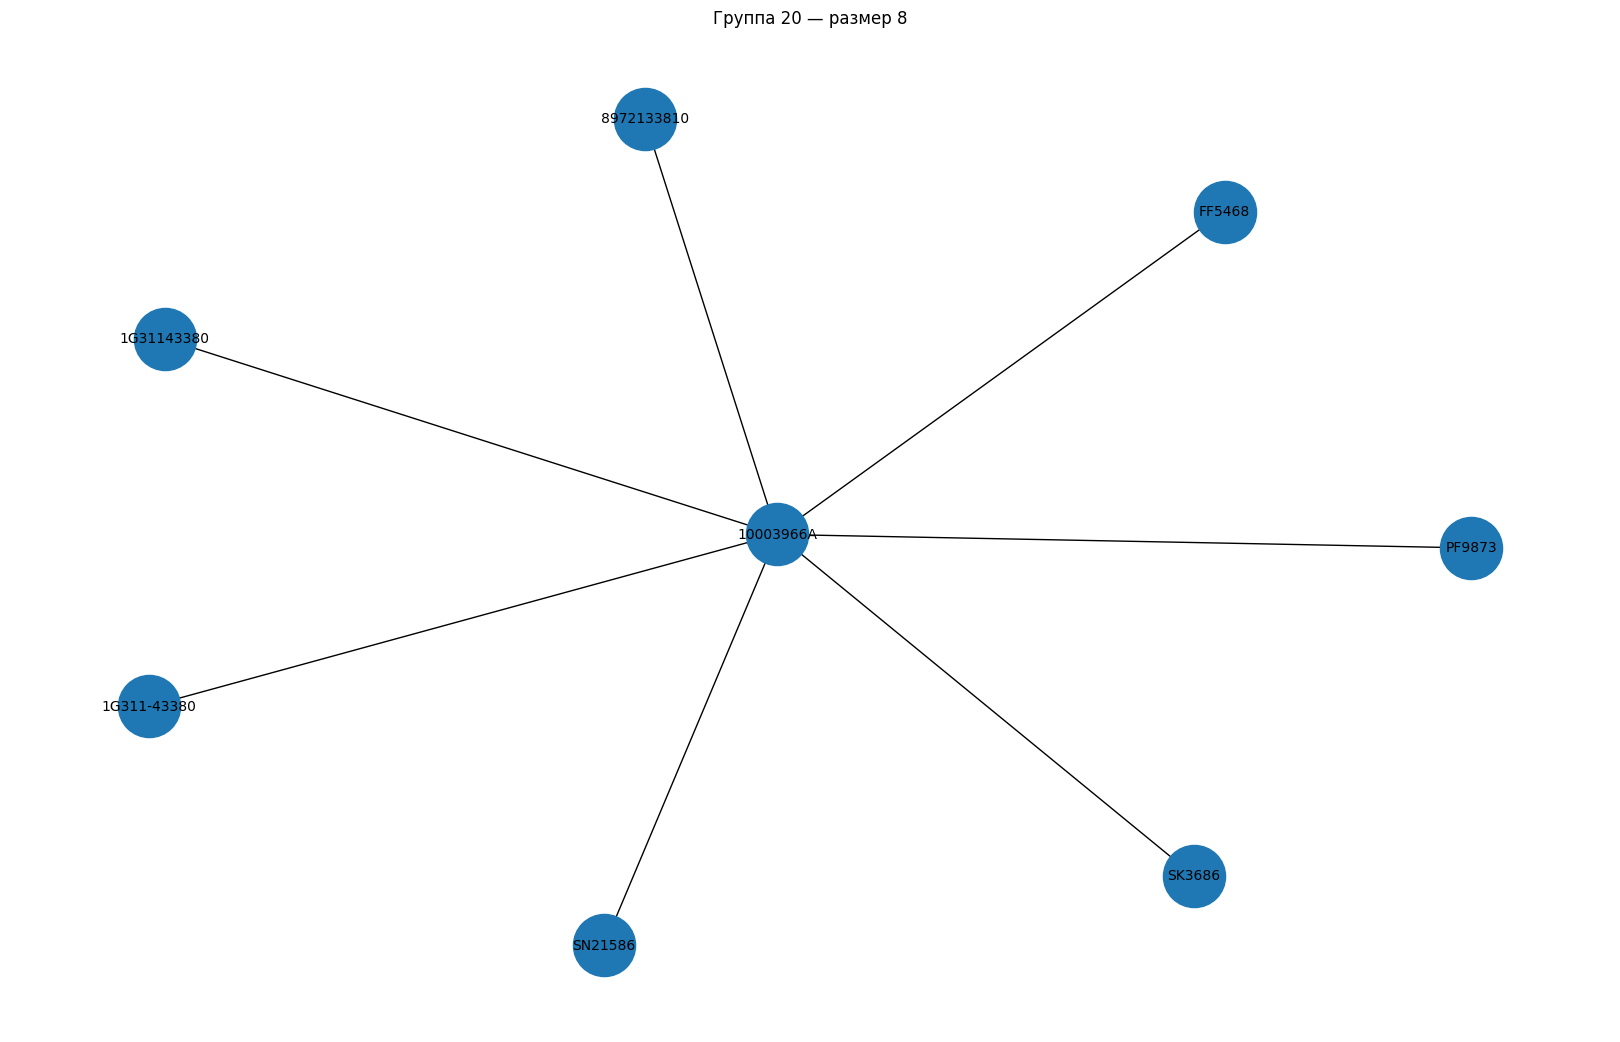

In [1015]:
all_groups = []
seen = set()

for node in graph:
    if node not in seen:
        group_nodes = find_all_analogs(node, graph) | {node}
        all_groups.append(group_nodes)
        seen |= group_nodes


all_groups.sort(key=len, reverse=True)


top_n = 20
top_groups = all_groups[:top_n]

for i, group in enumerate(top_groups, 1):
    G = nx.Graph()
    for node in group:
        for neighbor in graph[node]:
            if neighbor in group:
                G.add_edge(node, neighbor)
    
    plt.figure(figsize=(16,10))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10)
    plt.title(f"Группа {i} — размер {len(group)}")
    plt.show()

In [1016]:
def join_ordered(series):
    vals = series.dropna().astype(str).str.strip()
    vals = [v for v in vals if v]
    seen = set()
    result = []
    for v in vals:
        if v not in seen:
            seen.add(v)
            result.append(v)
    return "; ".join(result) if result else None

def longest_value(series):
    vals = series.dropna().astype(str).str.strip()
    if len(vals) == 0:
        return None
    return max(vals, key=len)

def count_unique(series):
    vals = series.dropna().astype(str).str.strip()
    vals = [v for v in vals if v]
    return len(set(vals))

def merge_parts(df):

    df = df.copy()
    df['Количество'] = df['Количество'].astype(float).astype(int)
    df['Лот.CRM наработка'] = df['Лот.CRM наработка'].apply(lambda x: str(x).replace(',',''))
    df['Лот.CRM наработка'] = df['Лот.CRM наработка'].astype(float).astype('Int64')
    df['Лот.CRM год выпуска'] = df['Лот.CRM год выпуска'].astype(float).astype('Int64')

    meta = (
        df.groupby("Номер группы", as_index=False)
        .agg({
            "Номенклатура": longest_value,
            "Машина.Бренд": join_ordered,
            "Машина.Серия техники": join_ordered,
            "Тип подъемника": join_ordered,
            "Тип двигателя": join_ordered,
            'Номенклатура.Тип техники': join_ordered,
            "Тип траты": 'last',
            'Документ.Склад': join_ordered,
            "all_analogs": "first"
        })
    )

    qty = (
        df.groupby(
            ["Год", "Квартал", "Номер группы"],
            as_index=False
        )
        .agg({
            "Количество": "sum",
            'Лот.CRM год выпуска': 'mean',
            'Серийный номер': count_unique,
            'Лот.CRM наработка': 'mean'
        })
    )

    result = qty.merge(meta, on="Номер группы", how="left")

    return result

In [1017]:
df_quarter = merge_parts(df1)

In [1018]:
df_quarter.to_excel('Запчасти списанные в ремонт аггрегированные.xlsx', index=False)

In [1019]:
# # Фильтра
# filters = df1[
#     df1['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(фильтр|комплект фильтров|элемент фильтра)',
#         regex=True,
#         na=False
#     )
# ]

# filters.to_excel('Фильра.xlsx', index=False)
# df1 = df1.drop(filters.index).reset_index(drop=True)

In [1020]:
# df1.to_excel('leftovers.xlsx', index=False)

In [1021]:
# # Замки
# locks = df[
#     df['Номенклатура'].str.contains('замок', case=False, na=False)
# ]

# locks.to_excel('Замки.xlsx', index=False)

# # Кнопки
# buttons = df[
#     df['Номенклатура'].str.contains('кнопка', case=False, na=False)
# ]

# buttons.to_excel('Кнопки.xlsx', index=False)

# # Батареи
# bat = df[
#     df['Номенклатура'].str.contains('батарея', case=False, na=False)
# ]

# bat.to_excel('Батареи.xlsx', index=False)

# # Обогреватели
# heater = df[
#     df['Номенклатура'].str.contains('|'.join(['обогреватель', 'нагреватель', 'подогреватель']), case=False, na=False)
# ]

# heater.to_excel('Обогреватели.xlsx', index=False)

# # Разъемы
# socket = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(разъем)',
#         regex=True,
#         na=False
#     )
# ]

# socket.to_excel('Разъемы.xlsx', index=False)

# # Пластины
# plate = df[
#     df['Номенклатура'].str.contains('пластина', case=False, na=False)
# ]

# plate.to_excel('Пластины.xlsx', index=False)

# # Масла
# oil = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(масло)',
#         regex=True,
#         na=False
#     )
# ]

# oil.to_excel('Масла.xlsx', index=False)

# # Ключи
# key = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(ключ)',
#         regex=True,
#         na=False
#     )
# ]

# key.to_excel('Ключи.xlsx', index=False)

# # Джойстики
# mask_include = df['Номенклатура'].str.contains('|'.join(['джойстик', 'электроджойстик']), case=False, na=False)
# mask_exclude = ~df['Номенклатура'].str.contains('рукоятка', case=False, na=False)

# joystick = df[mask_include & mask_exclude]

# joystick.to_excel('Джойстики.xlsx', index=False)

# # Рукава
# sleeve = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(рукав)',
#         regex=True,
#         na=False
#     )
# ]

# sleeve.to_excel('Рукава.xlsx', index=False)

# # Кабели
# cables = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(кабель)',
#         regex=True,
#         na=False
#     )
# ]

# cables.to_excel('Кабеля.xlsx', index=False)

# # Тройники
# splitter = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(тройник)',
#         regex=True,
#         na=False
#     )
# ]

# splitter.to_excel('Тройники.xlsx', index=False)

# # Штуцера
# fitting = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(штуцер)',
#         regex=True,
#         na=False
#     )
# ]

# fitting.to_excel('Штуцера.xlsx', index=False)

# # ЗУ
# charger = df[
#     df['Номенклатура'].str.contains('|'.join(['зу', 'устройство зарядное', 'Устройство зарядное', 'Зарядное устройство', 'зарядное устройство']), case=False, na=False)
# ]
# charger = charger[charger['Номенклатура'] != 'ЗУБР МЕХАНИК, размер L, перчатки маслобензостойкие тонкие 11276-L_z01']

# charger.to_excel('ЗУ.xlsx', index=False)

# # Клапаны
# valve = df[
#     df['Номенклатура'].str.contains('|'.join(['клапан']), case=False, na=False)
# ]
# lst = [
#     'Блок клапанов 92049371A',
#     'Прокладка клапанной крышки 713115700',
#     'Гидроцилиндр поворота люльки ZA20 (х8) 1010201471 без блока клапанов',
#     'Соленоид электромагнитного клапана поворота колёс 92047788'
# ]
# valve = valve[~valve['Номенклатура'].isin(lst)]
# valve.to_excel('Клапана.xlsx', index=False)

# # Наклейки
# stickers = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(наклейка)',
#         regex=True,
#         na=False
#     )
# ]
# stickers.to_excel('Наклейки.xlsx', index=False)

# # Тройники
# splitter = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(тройник)',
#         regex=True,
#         na=False
#     )
# ]

# splitter.to_excel('Тройники.xlsx', index=False)

# # Маячки
# beacons = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(маячок)',
#         regex=True,
#         na=False
#     )
# ]
# beacons.to_excel('Маячки.xlsx', index=False)

# # Датчики
# sensors = df[
#     df['Номенклатура'].str.contains('|'.join(['датчик']), case=False, na=False)
# ]
# lst = ['Кронштейн датчика угла 93300721', 'Контакт датчика поворота колеса BA36-44 93300156A',
#        'Скоба датчика BA36,BA44 50011001A', 'Контакт датчика поворота колеса BA36-44 93300156A'
# ]
# sensors = sensors[~sensors['Номенклатура'].isin(lst)]
# sensors.to_excel('Датчики.xlsx', index=False)

# # Чехлы
# cover = df[
#     df['Номенклатура'].str.contains('|'.join(['чехол', 'термочехол']), case=False, na=False)
# ]
# cover.to_excel('Чехлы.xlsx', index=False)

# # Жгуты
# harness = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(жгут)',
#         regex=True,
#         na=False
#     )
# ]
# harness.to_excel('Жгуты.xlsx', index=False)

# # Пальцы
# fingers = df[
#     df['Номенклатура']
#     .astype(str)
#     .str.lower()
#     .str.contains(
#         r'^(палец)',
#         regex=True,
#         na=False
#     )
# ]
# fingers.to_excel('Пальцы.xlsx', index=False)

# df['Номенклатура'].value_counts()[:20]

In [1022]:
# filters_list = set(filters['Номенклатура'])
# sensors_list = set(sensors['Номенклатура'])
# fingers_list = set(fingers['Номенклатура'])
# harness_list = set(harness['Номенклатура'])
# cover_list = set(cover['Номенклатура'])
# beacons_list = set(beacons['Номенклатура'])
# splitter_list = set(splitter['Номенклатура'])
# stickers_list = set(stickers['Номенклатура'])
# valve_list = set(valve['Номенклатура'])
# charger_list = set(charger['Номенклатура'])
# fitting_list = set(fitting['Номенклатура'])
# cables_list = set(cables['Номенклатура'])
# sleeve_list = set(sleeve['Номенклатура'])
# joystick_list = set(joystick['Номенклатура'])
# key_list = set(key['Номенклатура'])
# oil_list = set(oil['Номенклатура'])
# plate_list = set(plate['Номенклатура'])
# socket_list = set(socket['Номенклатура'])
# heater_list = set(heater['Номенклатура'])
# bat_list = set(bat['Номенклатура'])
# buttons_list = set(buttons['Номенклатура'])
# locks_list = set(locks['Номенклатура'])

In [1023]:
# df['Категория'] = 'другое'

# df.loc[df['Номенклатура'].isin(filters_list), 'Категория'] = 'фильтр'
# df.loc[df['Номенклатура'].isin(sensors_list), 'Категория'] = 'датчик'
# df.loc[df['Номенклатура'].isin(fingers_list), 'Категория'] = 'палец'
# df.loc[df['Номенклатура'].isin(harness_list), 'Категория'] = 'жгут'
# df.loc[df['Номенклатура'].isin(cover_list), 'Категория'] = 'чехол'
# df.loc[df['Номенклатура'].isin(beacons_list), 'Категория'] = 'маячок'
# df.loc[df['Номенклатура'].isin(splitter_list), 'Категория'] = 'тройник'
# df.loc[df['Номенклатура'].isin(stickers_list), 'Категория'] = 'наклейка'
# df.loc[df['Номенклатура'].isin(valve_list), 'Категория'] = 'клапан'
# df.loc[df['Номенклатура'].isin(charger_list), 'Категория'] = 'зу'
# df.loc[df['Номенклатура'].isin(fitting_list), 'Категория'] = 'штуцер'
# df.loc[df['Номенклатура'].isin(cables_list), 'Категория'] = 'кабель'
# df.loc[df['Номенклатура'].isin(sleeve_list), 'Категория'] = 'рукав'
# df.loc[df['Номенклатура'].isin(joystick_list), 'Категория'] = 'джойстик'
# df.loc[df['Номенклатура'].isin(key_list), 'Категория'] = 'ключ'
# df.loc[df['Номенклатура'].isin(oil_list), 'Категория'] = 'масло'
# df.loc[df['Номенклатура'].isin(plate_list), 'Категория'] = 'пластина'
# df.loc[df['Номенклатура'].isin(socket_list), 'Категория'] = 'разъем'
# df.loc[df['Номенклатура'].isin(heater_list), 'Категория'] = 'обогреватель'
# df.loc[df['Номенклатура'].isin(bat_list), 'Категория'] = 'батарея'
# df.loc[df['Номенклатура'].isin(buttons_list), 'Категория'] = 'кнопка'
# df.loc[df['Номенклатура'].isin(locks_list), 'Категория'] = 'замок'

In [1024]:
data2 = pd.read_csv('Остатки и обороты.csv', skiprows=[0, 1, 2, 3, 4, 5, 6, 7], dtype=str)
data2 = data2.iloc[:-2].reset_index(drop=True)
data2 = data2.rename(columns={'Артикул ': 'Артикул'})

period_mask = data2['Номенклатура'].str.contains(
    r'\d{4} г\.|\d квартал \d{4} г\.|Январь|Февраль|Март|Апрель|Май|Июнь|Июль|Август|Сентябрь|Октябрь|Ноябрь|Декабрь',
    na=False
)
# display(data2[period_mask])
data2['year'] = data2['Номенклатура'].str.extract(r'\b(20[2-9]\d)\b')
data2['quarter'] = data2['Номенклатура'].str.extract(r'(\d квартал)')
data2['month'] = data2['Номенклатура'].str.extract(
    r'(Январь|Февраль|Март|Апрель|Май|Июнь|Июль|Август|Сентябрь|Октябрь|Ноябрь|Декабрь)'
)
data2[['year','quarter','month']] = data2[['year','quarter','month']].ffill()
data2 = data2[~period_mask]

data2['Квартал'] = data2['quarter'].str.extract(r'(\d)').astype(int)

month_map = {
    'Январь': 1, 'Февраль': 2, 'Март': 3, 'Апрель': 4, 'Май': 5, 'Июнь': 6,
    'Июль': 7, 'Август': 8, 'Сентябрь': 9, 'Октябрь': 10, 'Ноябрь': 11, 'Декабрь': 12
}
data2['Месяц'] = data2['month'].map(month_map).astype(int)
data2['Год'] = data2['year']
data2.drop(columns=['Unnamed: 0', 'month', 'quarter', 'year'], inplace=True)
data2 = data2.loc[(data2['Артикул'].notna()) | (data2['Оригинальный номер'].notna())]
data2['Тип траты'] = 2
# data2.to_excel('test2.xlsx', index=False)

In [1025]:
df2 = copy.deepcopy(data2)

In [1026]:
cols = [
    'Артикул',
    'Оригинальный номер',
]

df2[cols] = df2[cols].replace(r'DIFA\s*', '', regex=True)

df2[cols] = df2[cols].replace(r'\s+', ' ', regex=True).apply(lambda x: x.str.strip())

mask_plus = (
    df2['Номенклатура'].str.contains(r'\+', na=False) &
    ~df2['Номенклатура'].str.contains(
        r'^(Колесо|РВД|[Оо]богреватель|Распределитель|Насос|Комплект|Кабель|Гидроцилиндр|Датчик|Коллектор|Фильтр топливный PERKINS|Фильтр воздушный \(внешний\+внутренний\) A5541S)',
        na=False
    )
)

mask_st_units = df2['Номенклатура'].str.contains(
    r'Фильтр воздушный ST40111/40110',
    case=False,
    na=False
)
mask_brackets = df2['Номенклатура'].str.contains(
    r'(95*165*340/70*90*335,',
    case=False,
    na=False,
    regex=False
)

mask_kt = df2['Номенклатура'].str.contains(
    r'Фильтр воздушный AF26656 к-т',
    case=False,
    na=False,
)

mask_AB = df2['Номенклатура'].str.contains(
    r'Фильтр воздушный ST40131AB',
    case=False,
    na=False,
)

mask_hid = df2['Номенклатура'].str.contains(
    r'Фильтр воздушный ST40111ST40110',
    case=False,
    na=False,
)


complects2 = df2[mask_plus | mask_st_units | mask_brackets | mask_kt | mask_AB | mask_hid]
complects2.loc[complects2['Номенклатура'] == 'Фильтр воздушный AF26656 к-т', 'Номенклатура'] = 'Фильтр воздушный к-т AF26656+AF26655'
complects2.loc[complects2['Номенклатура'] == 'Фильтр воздушный ST40131AB', 'Номенклатура'] = 'Фильтр воздушный (95*165*340/70*90*335, сдвоенный) kw1634'

df2 = df2[~df2.index.isin(complects2.index)]

C:\Users\a.vorona\AppData\Local\Temp\ipykernel_20496\3098952794.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df2['Номенклатура'].str.contains(


In [1027]:
complects2['Артикул'] = complects2['Номенклатура'].apply(lambda x: extract_articles(x, matches.keys()))

df_exploded = complects2.explode('Артикул').reset_index(drop=True)

# Подставляем оригинальный номер из словаря
df_exploded['Оригинальный номер'] = df_exploded['Артикул'].map(lambda x: matches[x].split()[0] if x in matches else None)

df_exploded[df_exploded['Артикул'].isna()]
assert (df_exploded.shape[0] == complects2.shape[0] * 2)
# Объединяем DataFrame'ы
df2 = pd.concat([df2, df_exploded], ignore_index=True)

In [1028]:
df1["_art_upper"] = df1["Номенклатура.Артикул"].str.strip().str.upper()
article_to_group   = dict(zip(df1["_art_upper"], df1["Номер группы"]))
article_to_analogs = dict(zip(df1["_art_upper"], df1["all_analogs"]))

df2["_art_norm"]  = df2["Артикул"].str.strip().str.upper()
df2["_orig_norm"] = df2["Оригинальный номер"].str.strip().str.upper()


def normalize(val):
    """Приводим к верхнему регистру, убираем лишние пробелы."""
    if pd.isna(val) or str(val).strip() in ("", "None", "nan"):
        return None
    return str(val).strip().upper()

df2["_art_norm"]  = df2["Артикул"].apply(normalize)
df2["_orig_norm"] = df2["Оригинальный номер"].apply(normalize)


def lookup(art_norm, orig_norm):
    if art_norm and art_norm in article_to_group:
        return article_to_group[art_norm], article_to_analogs[art_norm]
    if orig_norm and orig_norm in article_to_group:
        return article_to_group[orig_norm], article_to_analogs[orig_norm]
    return None, None

groups, analogs_list = zip(
    *df2.apply(lambda r: lookup(r["_art_norm"], r["_orig_norm"]), axis=1)
)

df2["Номер группы"] = groups
df2["all_analogs"]  = analogs_list

matched   = df2["Номер группы"].notna().sum()
unmatched = df2["Номер группы"].isna().sum()
total = len(df2)

print(f"\nВсего строк:           {total}")
print(f"Нашли группу:          {matched}  ({matched/total*100:.1f}%)")
print(f"Не нашли (нет аналога): {unmatched} ({unmatched/total*100:.1f}%)")

print("\nПримеры строк без совпадения (первые 10):")
no_match = df2[df2["Номер группы"].isna()][
    ["Номенклатура", "Артикул", "Оригинальный номер"]
].drop_duplicates().head(10)
print(no_match.to_string(index=False))

df2 = df2.drop(columns=["_art_norm", "_orig_norm"])


Всего строк:           46670
Нашли группу:          38722  (83.0%)
Не нашли (нет аналога): 7948 (17.0%)

Примеры строк без совпадения (первые 10):
                                                           Номенклатура  Артикул Оригинальный номер
                                            Фильтр воздушный 4000211710  2740510         4000211710
                                            Фильтр воздушный 4000211720  2740538         4000211720
                                            Фильтр воздушный 4000044240  3978897         4000044240
                                              Фильтр топливный 01174482   978434           01174482
          Сальник коленвала задний Deutz (04102866) 04175433 для BA44RT   100000           04175433
                                     Фильтр воздушный внутренний HP2587   TA1272         4000044240
                                         Фильтр гидравлический HLX-8690 HLX-8690         1019902592
Кабель канал открытого типа TEZ45.125D R75 внутр. 45

In [1029]:
# стартовый номер для новых групп
new_group = df1["Номер группы"].max() + 1

# для строк без найденной группы
for idx in df2[df2["Номер группы"].isna()].index:
    art = df2.at[idx, "Артикул"]
    orig = df2.at[idx, "Оригинальный номер"]

    # создаём список аналогов: артикул + оригинальный номер (если есть и отличается)
    analogs = [art]
    if pd.notna(orig) and str(orig).strip().upper() != str(art).strip().upper():
        analogs.append(orig)

    # сортируем кортеж аналогов
    analogs_sorted = tuple(sorted(analogs, key=lambda x: str(x).upper()))
    df2.at[idx, "all_analogs"] = analogs_sorted

# --- создаём новые группы только для строк, где их нет ---
unique_new_analogs = df2.loc[df2["Номер группы"].isna(), "all_analogs"].drop_duplicates()
group_mapping = {grp: new_group + i for i, grp in enumerate(unique_new_analogs)}

# присваиваем Номер группы для новых аналогов
df2.loc[df2["Номер группы"].isna(), "Номер группы"] = df2.loc[df2["Номер группы"].isna(), "all_analogs"].map(group_mapping)

In [1030]:
for i in range(0, 1000):
    group_rows = df2.loc[df2['Номер группы'] == i]
    
    if not group_rows.empty:
        # Берём размер группы через первый элемент all_analogs
        group_size = len(group_rows.iloc[0]['all_analogs'])
        
        if group_size > 2:
            display(group_rows[['Номенклатура', 'Артикул', 'all_analogs']].value_counts())

Номенклатура                            Артикул   all_analogs                            
Разъем НПУ в сборе с проводом Zoomlion  Я0378323  (12.02.000009, Z12.02.000009, Я0378323)    480
Name: count, dtype: int64

Номенклатура                             Артикул   all_analogs                            
Разъем ВПУ  в сборе с проводом Zoomlion  Я0378316  (12.02.000010, Z12.02.000010, Я0378316)    435
Разъем ВПУ (папа)                        Я0378316  (12.02.000010, Z12.02.000010, Я0378316)     36
Name: count, dtype: int64

Номенклатура          Артикул   all_analogs                            
Кнопка Стоп 122514GT  122514GT  (122514GT, 26.01.000002, Y26.01.000002)    515
Name: count, dtype: int64

Номенклатура                                                      Артикул        all_analogs                                                                                                          
Замок зажигания с ключом IHP-30 (1020520943) 1020521389 ZOOMLION  1020521389     (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 89943-29, 90173, IHP-30, Y26.01.000023, Y26.01.000024)    623
Замок зажигания с ключом 84830/90173  4130000723001 LGMG          4130000723001  (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 89943-29, 90173, IHP-30, Y26.01.000023, Y26.01.000024)    602
Замок зажигания с ключом 84830 ZOOMLION                           84830          (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 89943-29, 90173, IHP-30, Y26.01.000023, Y26.01.000024)    516
Ключ зажигания 4130000723001 LGMG                                 4130000723001  (1020521389, 26.01.000023, 26.01.000024, 4130000723001, 84830, 89943-29, 90173, IHP-30, Y26.01.000023,

Номенклатура                 Артикул       all_analogs                                                     
Кнопка "Масса" 26.01.000003  26.01.000003  (00000655, 26.01.000003, 4130001123, DL-00000655, Y26.01.000003)    105
Кнопка "Масса" 4130001123    4130001123    (00000655, 26.01.000003, 4130001123, DL-00000655, Y26.01.000003)     57
Контактор 00000655           00000655      (00000655, 26.01.000003, 4130001123, DL-00000655, Y26.01.000003)     38
Name: count, dtype: int64

...

Номенклатура                   Артикул   all_analogs                  
Насос подкачки Deutz 04128101  04128101  (04128101, 90029469, kr0032p)    16
Бензонасос электрический       kr0032p   (04128101, 90029469, kr0032p)     4
Name: count, dtype: int64

Номенклатура              Артикул  all_analogs                       
Фильтр топливный FC-1804  FC-1804  (4110001811373, FC-1804, FK28316K)    56
Name: count, dtype: int64

Номенклатура            Артикул  all_analogs                         
Стартер Yanmar TT16046  TT16046  (129136-77011, 12913677011, TT16046)    24
Name: count, dtype: int64

Номенклатура                                       Артикул      all_analogs                                                                      
Фильтр топливный ГО BA16-22CRT 10003966A (Kubota)  10003966A    (10003966A, 1G311-43380, 1G31143380, 8972133810, FF5468, PF9873, SK3686, SN21586)    11
                                                   1g311-43380  (10003966A, 1G311-43380, 1G31143380, 8972133810, FF5468, PF9873, SK3686, SN21586)    10
Name: count, dtype: int64

Номенклатура                                         Артикул   all_analogs                        
Блок управления JLG 600S, 600AJ, 800S, 800AJ, 740AJ  Я0387359  (10011036577, 1001103667, Я0387359)    5
Name: count, dtype: int64

In [1031]:
df2

,Номенклатура,Артикул,Оригинальный номер,Тип техники,Склад,Начальный остаток,Приход,Расход,Конечный остаток,Квартал,Месяц,Год,Тип траты,Номер группы,all_analogs
0,"Нагреватель ленточный 12В, 1м ЭЛАН 12-1-30-180...",ЭЛАН 12-1-30-180 ПРО,NaN,ЗЧ ПО,БТС Склад запчастей,6.000,NaN,1.000,5.000,1,1,2023,2,260.0,"(ЭЛАН 12-1-30-180 ПРО,)"
1,"Нагреватель ленточный 12В, 1м ЭЛАН 12-1-30-180...",ЭЛАН 12-1-30-180 ПРО,NaN,ЗЧ ПО,БТС Склад запчастей,7.000,NaN,1.000,6.000,1,1,2023,2,260.0,"(ЭЛАН 12-1-30-180 ПРО,)"
2,"Нагреватель ленточный 12В, 1м ЭЛАН 12-1-30-180...",ЭЛАН 12-1-30-180 ПРО,NaN,ЗЧ ПО,БТС Склад запчастей,8.000,NaN,1.000,7.000,1,1,2023,2,260.0,"(ЭЛАН 12-1-30-180 ПРО,)"
3,"Нагреватель ленточный 12В, 1м ЭЛАН 12-1-30-180...",ЭЛАН 12-1-30-180 ПРО,NaN,ЗЧ ПО,БТС Склад запчастей,9.000,NaN,1.000,8.000,1,1,2023,2,260.0,"(ЭЛАН 12-1-30-180 ПРО,)"
4,"Нагреватель ленточный 12В, 1м ЭЛАН 12-1-30-180...",ЭЛАН 12-1-30-180 ПРО,NaN,ЗЧ ПО,БТС Склад запчастей,9.000,NaN,NaN,9.000,1,1,2023,2,260.0,"(ЭЛАН 12-1-30-180 ПРО,)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46665,Фильтр воздушный ST40111/40110,ST40111,90031459,ЗЧ DINGLI,Благовещенск. Склад Запчастей,17.000,NaN,1.000,16.000,1,3,2026,2,113.0,"(32/925683, 43121-01, 90031459, AF26655, P6009..."
46666,Фильтр воздушный ST40111/40110,ST40110,90031461,ЗЧ DINGLI,Благовещенск. Сервисное обслуживание,NaN,1.000,1.000,NaN,1,3,2026,2,147.0,"(32/925682, 32925682, 43121, 90029290, 9003146..."
46667,Фильтр воздушный ST40111/40110,ST40111,90031459,ЗЧ DINGLI,Благовещенск. Сервисное обслуживание,NaN,1.000,1.000,NaN,1,3,2026,2,113.0,"(32/925683, 43121-01, 90031459, AF26655, P6009..."
46668,"Фильтр воздушный (95*165*340/70*90*335, сдвоен...",kw1634in,201020003058,ЗЧ SINOBOOM,Красноярск. Склад запчастей,9.000,NaN,NaN,9.000,1,3,2026,2,702.0,"(201020003058, kw1634in)"


In [1032]:
def merge_parts2(df):
    df = df.copy()

    # Приводим к float, чтобы убрать строки и символы
    for col in ["Расход", "Приход", "Конечный остаток"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.replace(' ', '', regex=False)
            .astype(float)
        )

    # Метаданные по группе
    meta = (
        df.groupby("Номер группы", as_index=False)
        .agg({
            "Номенклатура": longest_value,
            'Склад': join_ordered,
            "all_analogs": "first",
            "Тип техники": join_ordered,
            'Артикул': 'first',
            "Тип траты": 'last'
        })
    )

    # Суммы и остатки по год/квартал/группа
    qty = (
        df.groupby(["Год", "Квартал", "Номер группы"], as_index=False)
        .agg({
            "Расход": "sum",
            "Приход": "sum",
            "Конечный остаток": 'last'
        })
    )

    # Преобразуем суммы в int, если они целые
    for col in ["Расход", "Приход", "Конечный остаток"]:
        qty[col] = qty[col].apply(lambda x: int(x) if x.is_integer() else x)

    result = qty.merge(meta, on="Номер группы", how="left")
    return result

In [1033]:
agg = merge_parts2(df2)

In [1034]:
agg

,Год,Квартал,Номер группы,Расход,Приход,Конечный остаток,Номенклатура,Склад,all_analogs,Тип техники,Артикул,Тип траты
0,2023,1,1.0,180.0,152.0,24.0,Гибкая нагревающая пластина 400 Вт 24 В (152х2...,ПО Запасные части; БТС Склад запчастей; ПТО С...,"(400-24-0-0-3M-15,)",ЗЧ ПО,400-24-0-0-3M-15,2
1,2023,1,2.0,64.0,68.0,1.0,Обогреватель предпусковой БИНАР-5S (дизель) 12 в,ПО Запасные части; ПО Сервисное обслуживание; ...,"(НФ-00000397,)",ЗЧ ПО,НФ-00000397,2
2,2023,1,3.0,20.0,10.0,3.0,Разъем НПУ в сборе с проводом Zoomlion,ПТО СПЕКТР Запчасти и ГСМ; ПТО СК запчасти дл...,"(12.02.000009, Z12.02.000009, Я0378323)",ЗЧ ZOOMLION,Я0378323,2
3,2023,1,4.0,20.0,10.0,3.0,Разъем ВПУ в сборе с проводом Zoomlion,ПТО СПЕКТР Запчасти и ГСМ; ПТО СК запчасти дл...,"(12.02.000010, Z12.02.000010, Я0378316)",ЗЧ ZOOMLION,Я0378316,2
4,2023,1,5.0,2.0,1.0,1.0,Переключатель 4130702176,ПО Запасные части; ПТО СК запчасти для арендно...,"(4130702176,)",ЗЧ LGMG,4130702176,2
...,...,...,...,...,...,...,...,...,...,...,...,...
6799,2026,1,2256.0,0.0,30.0,30.0,Фильтр гидравлический напорный ST30225,БТС Склад запчастей,"(00004697, ST30225)",ЗЧ DINGLI,ST30225,2
6800,2026,1,2257.0,0.0,1.0,1.0,Насос масляный 04280145,Ростов-на-Дону. Склад запчастей,"(04280145, F3M2011)",ЗЧ ПО,04280145,2
6801,2026,1,2258.0,0.0,3.0,3.0,Цилиндр WG0200010,ПО Склад гарантии ЗАПЧАСТИ,"(WG0200010,)",ЗЧ AURORA HELI,WG0200010,2
6802,2026,1,2259.0,1.0,1.0,1.0,Колесо в сборе 105051034051A,ПО Склад гарантии ЗАПЧАСТИ,"(105051034051A, nan)",Колеса ПО,NaN,2


In [1035]:
# Создаем копию, чтобы не портить исходный agg
agg_mod = agg.copy()

# Приводим типы к int, если ещё не сделано
agg_mod['Год'] = agg_mod['Год'].astype(int)
agg_mod['Квартал'] = agg_mod['Квартал'].astype(int)
df_quarter['Год'] = df_quarter['Год'].astype(int)
df_quarter['Квартал'] = df_quarter['Квартал'].astype(int)

# Делаем merge по Год, Квартал и Номер группы
merged = agg_mod.merge(
    df_quarter[['Год','Квартал','Номер группы','Количество']],
    on=['Год','Квартал','Номер группы'],
    how='left'
)

# Вычитаем Количество из Расхода (NaN считаем 0)
merged['Расход'] = merged['Расход'] - merged['Количество'].fillna(0)

# Можно удалить колонку Количество, если не нужна
merged = merged.drop(columns=['Количество'])

# Результат — обновленный agg
agg = merged

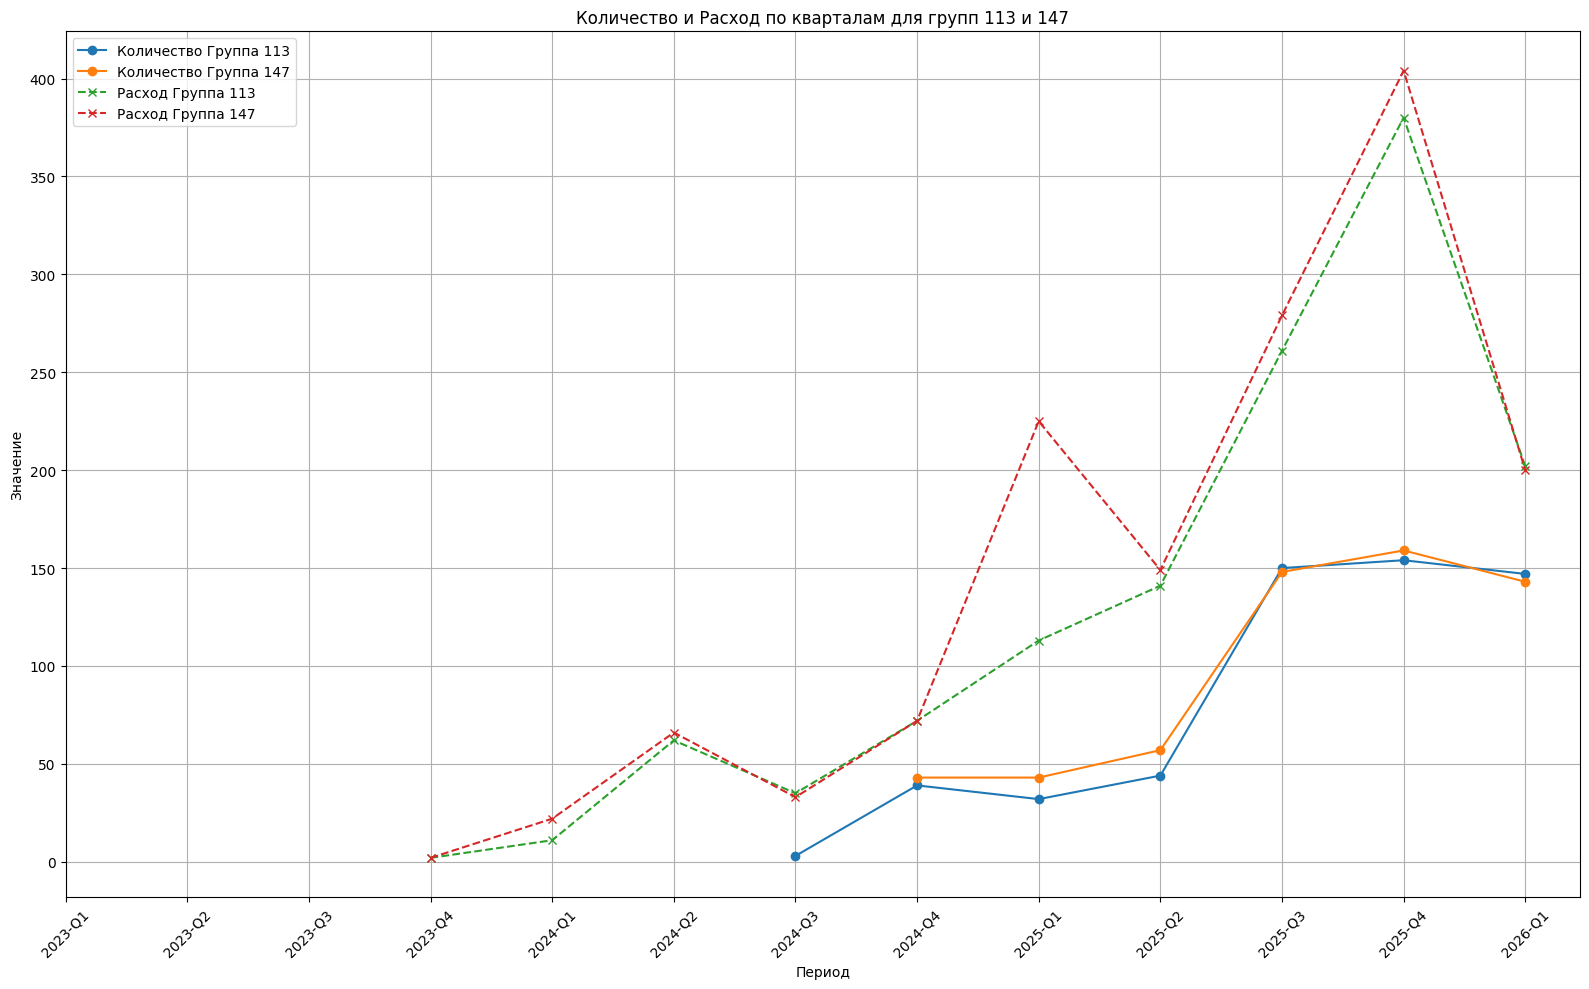

In [1036]:
plt.figure(figsize=(16,10))

groups = [113, 147]

# Собираем все уникальные периоды и сортируем
all_periods = pd.concat([
    df_quarter[['Год','Квартал']],
    agg[['Год','Квартал']]
]).drop_duplicates().sort_values(['Год','Квартал'])
x_labels = [f"{y}-Q{q}" for y,q in zip(all_periods['Год'], all_periods['Квартал'])]

# df1
for grp in groups:
    grp_data = df_quarter[df_quarter['Номер группы']==grp].copy()
    grp_data = grp_data.groupby(['Год','Квартал'], as_index=False)['Количество'].sum()
    # позиции по порядку на оси X
    x_pos = [x_labels.index(f"{y}-Q{q}") for y,q in zip(grp_data['Год'], grp_data['Квартал'])]
    plt.plot(x_pos, grp_data['Количество'], marker='o', label=f'Количество Группа {grp}')

# df2
for grp in groups:
    grp_data = agg[agg['Номер группы']==grp].copy()
    grp_data = grp_data.groupby(['Год','Квартал'], as_index=False)['Расход'].sum()
    x_pos = [x_labels.index(f"{y}-Q{q}") for y,q in zip(grp_data['Год'], grp_data['Квартал'])]
    plt.plot(x_pos, grp_data['Расход'], marker='x', linestyle='--', label=f'Расход Группа {grp}')

plt.xticks(range(len(x_labels)), x_labels, rotation=45)
plt.xlabel('Период')
plt.ylabel('Значение')
plt.title('Количество и Расход по кварталам для групп 113 и 147')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [1037]:
# Объединяем df_quarter и agg_mod по ключам
final_df = df_quarter.merge(
    agg_mod[['Год','Квартал','Номер группы','Расход']],
    on=['Год','Квартал','Номер группы'],
    how='outer'   # outer, чтобы включить все периоды из обоих
)

# Заполняем пропуски 0 (если для какой-то группы нет Расхода или Количества)
final_df['Количество'] = final_df['Количество'].fillna(0)
final_df['Расход'] = final_df['Расход'].fillna(0)

# Опционально создаём колонку для подписи периода
final_df['Период'] = final_df['Год'].astype(str) + '-Q' + final_df['Квартал'].astype(str)

In [1038]:
final_df[final_df['Номер группы'] == 113]

,Год,Квартал,Номер группы,Количество,Лот.CRM год выпуска,Серийный номер,Лот.CRM наработка,Номенклатура,Машина.Бренд,Машина.Серия техники,Тип подъемника,Тип двигателя,Номенклатура.Тип техники,Тип траты,Документ.Склад,all_analogs,Расход,Период
284,2023,4,113.0,0.0,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2023-Q4
460,2024,1,113.0,0.0,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,2024-Q1
764,2024,2,113.0,0.0,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,2024-Q2
1073,2024,3,113.0,3.0,2023.0,3.0,3279.666667,Фильтр воздушный внешний DIFA 43121 + внутренн...,Dingli; Zoomlion; LGMG; Sinoboom,BA; ZA; SR; JCPT; AB,коленчатый; ножничный,Дизельный,ЗЧ DINGLI,1.0,С-Петербург. Склад Запчасти; Набережные Челны....,"(32/925683, 43121-01, 90031459, AF26655, P6009...",38.0,2024-Q3
1360,2024,4,113.0,39.0,2023.589744,30.0,2784.74359,Фильтр воздушный внешний DIFA 43121 + внутренн...,Dingli; Zoomlion; LGMG; Sinoboom,BA; ZA; SR; JCPT; AB,коленчатый; ножничный,Дизельный,ЗЧ DINGLI,1.0,С-Петербург. Склад Запчасти; Набережные Челны....,"(32/925683, 43121-01, 90031459, AF26655, P6009...",111.0,2024-Q4
1908,2025,1,113.0,32.0,2023.5,26.0,2618.75,Фильтр воздушный внешний DIFA 43121 + внутренн...,Dingli; Zoomlion; LGMG; Sinoboom,BA; ZA; SR; JCPT; AB,коленчатый; ножничный,Дизельный,ЗЧ DINGLI,1.0,С-Петербург. Склад Запчасти; Набережные Челны....,"(32/925683, 43121-01, 90031459, AF26655, P6009...",145.0,2025-Q1
2389,2025,2,113.0,44.0,2024.0,39.0,2494.911765,Фильтр воздушный внешний DIFA 43121 + внутренн...,Dingli; Zoomlion; LGMG; Sinoboom,BA; ZA; SR; JCPT; AB,коленчатый; ножничный,Дизельный,ЗЧ DINGLI,1.0,С-Петербург. Склад Запчасти; Набережные Челны....,"(32/925683, 43121-01, 90031459, AF26655, P6009...",185.0,2025-Q2
3250,2025,3,113.0,150.0,2024.489796,102.0,2333.57554,Фильтр воздушный внешний DIFA 43121 + внутренн...,Dingli; Zoomlion; LGMG; Sinoboom,BA; ZA; SR; JCPT; AB,коленчатый; ножничный,Дизельный,ЗЧ DINGLI,1.0,С-Петербург. Склад Запчасти; Набережные Челны....,"(32/925683, 43121-01, 90031459, AF26655, P6009...",411.0,2025-Q3
4077,2025,4,113.0,154.0,2024.662252,98.0,1991.198675,Фильтр воздушный внешний DIFA 43121 + внутренн...,Dingli; Zoomlion; LGMG; Sinoboom,BA; ZA; SR; JCPT; AB,коленчатый; ножничный,Дизельный,ЗЧ DINGLI,1.0,С-Петербург. Склад Запчасти; Набережные Челны....,"(32/925683, 43121-01, 90031459, AF26655, P6009...",534.0,2025-Q4
5040,2026,1,113.0,147.0,2024.680272,113.0,1799.197279,Фильтр воздушный внешний DIFA 43121 + внутренн...,Dingli; Zoomlion; LGMG; Sinoboom,BA; ZA; SR; JCPT; AB,коленчатый; ножничный,Дизельный,ЗЧ DINGLI,1.0,С-Петербург. Склад Запчасти; Набережные Челны....,"(32/925683, 43121-01, 90031459, AF26655, P6009...",349.0,2026-Q1


In [1044]:
import pandas as pd

# Создаём булеву маску для всех трёх колонок
mask = (
    agg['Артикул'].astype(str).str.contains(r'[+/]') 
)

# Фильтруем строки
df2_filtered = agg[mask]

# Смотрим результат
df2_filtered['Артикул'].value_counts()

Артикул
Северс+ Премиум 2,0                 11
PCH35-b123-R82,5-2560-FAI/MAI        4
GB/T 297—1994                        4
00006753A/00005190A                  3
050209107+198636090                  3
40*55*6/6.5 TCN11 NBR                2
60090805/60510809                    2
PL271/1                              2
320/28 NSK                           2
68/Т13871                            2
QCC26C-100A/10B                      1
GB/T13871                            1
A2C19168300 Б/У                      1
320/28 JR                            1
261/706348                           1
50009032 б/у                         1
50009033 б/у                         1
FR08-20F-0-V/1.50 (5402301.1.50)     1
50х68х9/10.3+86х3.0                  1
GB/T297-1994                         1
320/28                               1
KW1330/D                             1
6666375/6666376                      1
Name: count, dtype: int64